# Weather Trend Analysis and Forecasting

## PM Accelerator Data Science Technical Assessment

**Author:** Rajaraman Rajagopalan  
**Dataset:** Global Weather Repository  
**Primary Forecast Target:** Temperature in Celsius  
**Forecast Horizon:** Seven Days  
**Development Environment:** Local Jupyter Notebook  

## Project Objective

This project analyzes daily weather observations from cities worldwide to identify temporal, environmental, climatic, and geographical patterns and forecast future temperature trends.

The project implements both the basic and advanced assessment requirements including:
- Data cleaning and preprocessing
- Missing-value and outlier handling
- Temperature and precipitation analysis
- Anomaly detection
- Climate and geographical analysis
- Air-quality analysis
- Spatial visualization
- Multiple forecasting models
- Ensemble forecasting
- Feature-importance analysis
- Future temperature forecasting

## PM Accelerator Mission

**Their mission is to break down financial barriers and achieve educational fairness.**

This project was developed as part of the PM Accelerator Data Science Technical Assessment.

## Assessment Requirements
### Basic Assessment

- [ ] Handle missing values
- [ ] Identify and handle outliers
- [ ] Normalize modeling features
- [ ] Perform exploratory data analysis
- [ ] Analyze trends, correlations, and patterns
- [ ] Generate temperature visualizations
- [ ] Generate precipitation visualizations
- [ ] Build a basic forecasting model
- [ ] Evaluate the model with multiple metrics
- [ ] Use the `last_updated` feature for time-series analysis

### Advanced Assessment

- [ ] Perform advanced exploratory data analysis
- [ ] Implement anomaly detection
- [ ] Analyze anomalous observations
- [ ] Build and compare multiple forecasting models
- [ ] Create an ensemble forecasting model
- [ ] Analyze climate and seasonal patterns
- [ ] Analyze air quality and weather relationships
- [ ] Apply multiple feature-importance techniques
- [ ] Perform spatial analysis
- [ ] Compare countries and continents

### Submission Deliverables

- [x] Display the PM Accelerator mission
- [ ] Complete the analysis notebook
- [ ] Create a separate PDF report
- [ ] Complete the README
- [x] Include a requirements file
- [x] Make the GitHub repository accessible
- [ ] Record a 1–2 minute demo video
- [ ] Add the demo video link

# 1. Environment Setup

# 2. Data Loading and Initial Inspection

# 3. Data Quality Assessment

# 4. Data Cleaning and Preprocessing

# 5. Basic Exploratory Data Analysis(EDA)

# 6. Temperature Analysis

# 7. Precipitation Analysis

# 8. Correlation Analysis

# 9. Anomaly Detection

# 10. Climate and Seasonal-Pattern Analysis

# 11. Environmental and Air-Quality Analysis

# 12. Spatial and Geographical Analysis

# 13. Forecasting Data Preparation

# 14. Baseline Forecasting Models

# 15. Statistical Forecasting Model

# 16. Machine-Learning Forecasting Models

# 17. Ensemble Forecasting

# 18. Model Evaluation and Comparison

# 19. Feature-Importance Analysis

# 20. Future Temperature Forecast

# 21. Key Findings

# 22. Limitations and Future Improvements

# 23. Conclusion

In [1]:
from pathlib import Path
from datetime import timedelta
import random
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
import country_converter as coco
from IPython.display import display
print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(12, 6)
plt.rcParams["axes.titlesize"]=14
plt.rcParams["axes.labelsize"]=11
print(f"Random state configured: {RANDOM_STATE}")

Random state configured: 42


In [3]:
DATASET_FILENAME="GlobalWeatherRepository.csv"
TARGET_COLUMN="temperature_celsius"
FORECAST_HORIZON=7
NUMBER_OF_FORECAST_CITIES=5
DATA_PATH = Path(DATASET_FILENAME)
PROJECT_CONFIG = {"Dataset filename": DATASET_FILENAME,"Target column": TARGET_COLUMN,"Forecast horizon": f"{FORECAST_HORIZON} days","Number of forecast cities": NUMBER_OF_FORECAST_CITIES,
    "Random state": RANDOM_STATE,}
config_df = pd.DataFrame(PROJECT_CONFIG.items(),columns=["Configuration", "Value"],)
display(config_df)

,Configuration,Value
0,Dataset filename,GlobalWeatherRepository.csv
1,Target column,temperature_celsius
2,Forecast horizon,7 days
3,Number of forecast cities,5
4,Random state,42


In [4]:
import sys
import sklearn
import scipy
import statsmodels
import plotly
package_versions = {
    "Python": sys.version.split()[0],
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "SciPy": scipy.__version__,
    "Scikit-learn": sklearn.__version__,
    "Statsmodels": statsmodels.__version__,
    "Plotly": plotly.__version__,
}
version_df = pd.DataFrame(package_versions.items(),columns=["Package", "Version"],)
display(version_df)

,Package,Version
0,Python,3.12.4
1,NumPy,2.5.1
2,Pandas,3.0.5
3,SciPy,1.18.0
4,Scikit-learn,1.9.0
5,Statsmodels,0.14.6
6,Plotly,6.9.0


### Data Loading and Initial Inspection

In [5]:
csv_files = list(Path.cwd().glob("*.csv"))
if not csv_files:
    raise FileNotFoundError("No CSV file was found.")
if len(csv_files) > 1:
    print("Multiple CSV files found:")
    for file in csv_files:
        print(f"{file.name}")
    raise ValueError(
        "Keep only the weather dataset CSV in the project directory")
DATA_PATH = csv_files[0]
print(f"Dataset selected: {DATA_PATH.name}")

Dataset selected: GlobalWeatherRepository.csv


In [6]:
df_raw = pd.read_csv(DATA_PATH,low_memory=False,)

df = df_raw.copy()

print("Successfully loaded the Dataset.")
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")

Successfully loaded the Dataset.
Rows: 154,556
Columns: 41


In [7]:
display(df_raw.head())

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.520,69.180,Asia/Kabul,1715849100,2024-05-16 13:15,26.600,79.800,Partly Cloudy,8.300,13.300,338,NNW,"1,012.000",29.890,0.000,0.000,24,30,25.300,77.500,10.000,6.000,7.000,9.500,15.300,277.000,103.000,1.100,0.200,8.400,26.600,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.330,19.820,Europe/Tirane,1715849100,2024-05-16 10:45,19.000,66.200,Partly cloudy,6.900,11.200,320,NW,"1,012.000",29.880,0.100,0.000,94,75,19.000,66.200,10.000,6.000,5.000,11.400,18.400,193.600,97.300,0.900,0.100,1.100,2.000,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.760,3.050,Africa/Algiers,1715849100,2024-05-16 09:45,23.000,73.400,Sunny,9.400,15.100,280,W,"1,011.000",29.850,0.000,0.000,29,0,24.600,76.400,10.000,6.000,5.000,13.900,22.300,540.700,12.200,65.100,13.400,10.400,18.400,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.500,1.520,Europe/Andorra,1715849100,2024-05-16 10:45,6.300,43.300,Light drizzle,7.400,11.900,215,SW,"1,007.000",29.750,0.300,0.010,61,100,3.800,38.900,2.000,1.000,2.000,8.500,13.700,170.200,64.400,1.600,0.200,0.700,0.900,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.840,13.230,Africa/Luanda,1715849100,2024-05-16 09:45,26.000,78.800,Partly cloudy,8.100,13.000,150,SSE,"1,011.000",29.850,0.000,0.000,89,50,28.700,83.600,10.000,6.000,8.000,12.500,20.200,"2,964.000",19.000,72.700,31.500,183.400,262.300,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [8]:
print("Shape of the dataset",df_raw.shape)

Shape of the dataset (154556, 41)


In [9]:
print("Columns in the Dataset:")
for i, c in enumerate(df_raw.columns,start=1):
    print(f"{i}. {c}")

Columns in the Dataset:
1. country
2. location_name
3. latitude
4. longitude
5. timezone
6. last_updated_epoch
7. last_updated
8. temperature_celsius
9. temperature_fahrenheit
10. condition_text
11. wind_mph
12. wind_kph
13. wind_degree
14. wind_direction
15. pressure_mb
16. pressure_in
17. precip_mm
18. precip_in
19. humidity
20. cloud
21. feels_like_celsius
22. feels_like_fahrenheit
23. visibility_km
24. visibility_miles
25. uv_index
26. gust_mph
27. gust_kph
28. air_quality_Carbon_Monoxide
29. air_quality_Ozone
30. air_quality_Nitrogen_dioxide
31. air_quality_Sulphur_dioxide
32. air_quality_PM2.5
33. air_quality_PM10
34. air_quality_us-epa-index
35. air_quality_gb-defra-index
36. sunrise
37. sunset
38. moonrise
39. moonset
40. moon_phase
41. moon_illumination


In [10]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 154556 entries, 0 to 154555
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       154556 non-null  str    
 1   location_name                 154556 non-null  str    
 2   latitude                      154556 non-null  float64
 3   longitude                     154556 non-null  float64
 4   timezone                      154556 non-null  str    
 5   last_updated_epoch            154556 non-null  int64  
 6   last_updated                  154556 non-null  str    
 7   temperature_celsius           154556 non-null  float64
 8   temperature_fahrenheit        154556 non-null  float64
 9   condition_text                154556 non-null  str    
 10  wind_mph                      154556 non-null  float64
 11  wind_kph                      154556 non-null  float64
 12  wind_degree                   154556 non-null  int64  


In [11]:
col_sum = pd.DataFrame({"column": df_raw.columns,"data_type": df_raw.dtypes.astype(str).values,"non_null_count": df_raw.notna().sum().values,"unique_values": df_raw.nunique(dropna=True).values,})
display(col_sum)

,column,data_type,non_null_count,unique_values
0,country,str,154556,211
1,location_name,str,154556,268
2,latitude,float64,154556,422
3,longitude,float64,154556,428
4,timezone,str,154556,201
5,last_updated_epoch,int64,154556,1428
6,last_updated,str,154556,25733
7,temperature_celsius,float64,154556,708
8,temperature_fahrenheit,float64,154556,1179
9,condition_text,str,154556,57


In [12]:
missing_summary = pd.DataFrame({"column": df_raw.columns,"missing_count": df_raw.isna().sum().values,"missing_percentage":df_raw.isna().mean().values*100,})
missing_summary=missing_summary.sort_values("missing_percentage",ascending=False,).reset_index(drop=True)
missing_columns=missing_summary[missing_summary["missing_count"]>0]
if missing_columns.empty:
    print("No missing values were found.")
else:
    display(missing_columns)

No missing values were found.


In [13]:
dup_count = df_raw.duplicated().sum()
print(f"Exact duplicate rows: {dup_count}")

Exact duplicate rows: 0


In [14]:
timestamp_candidates = ["last_updated","lastupdated","last_updated_date","date","datetime",]
Time_Col = next((column for column in timestamp_candidates if column in df_raw.columns),None,)
if Time_Col is None:
    raise KeyError("No expected timestamp column was found.")
parsed_timestamp = pd.to_datetime(df_raw[Time_Col],errors="coerce")
print(f"Timestamp column selected: {Time_Col}")
print(f"Valid timestamps: {parsed_timestamp.notna().sum():,}")
print(f"Invalid timestamps: {parsed_timestamp.isna().sum():,}")
print(f"Earliest timestamp: {parsed_timestamp.min()}")
print(f"Latest timestamp: {parsed_timestamp.max()}")

Timestamp column selected: last_updated
Valid timestamps: 154,556
Invalid timestamps: 0
Earliest timestamp: 2024-05-16 01:45:00
Latest timestamp: 2026-07-21 19:00:00


In [15]:
country_candidates = ["country","country_name",]
location_candidates = ["location_name","city","location",]
Coun_Col = next((column for column in country_candidates if column in df_raw.columns),None,)
Loc_Col = next((column for column in location_candidates if column in df_raw.columns),None,)
if Coun_Col is None or Loc_Col is None:
    raise KeyError("Country or location column was not found.")
print(f"Country column: {Coun_Col}")
print(f"Location column: {Loc_Col}")

Country column: country
Location column: location_name


In [16]:
number_of_countries = df_raw[Coun_Col].nunique(dropna=True)
number_of_locations = (df_raw[[Coun_Col, Loc_Col]].drop_duplicates().shape[0])
print(f"Unique countries: {number_of_countries}")
print(f"Unique country-location pairs: {number_of_locations}")

Unique countries: 211
Unique country-location pairs: 286


In [17]:
city_observation_counts = df_raw.groupby([Coun_Col, Loc_Col],dropna=False,).size().reset_index(name="observation_count").sort_values("observation_count",ascending=False,)
display(city_observation_counts.head(20))

,country,location_name,observation_count
36,Burundi,Bujumbura,795
260,Ukraine,Kyiv,795
278,Yemen,Sanaa,795
49,Chad,N'djamena,795
86,Ghana,Accra,795
272,Vatican City,Vatican City,795
74,Eritrea,Asmara,795
73,Equatorial Guinea,Malabo,795
149,Malta,Valletta,795
270,Uzbekistan,Tashkent,795


In [18]:
display(city_observation_counts["observation_count"].describe().rename("value").to_frame())

,value
count,286.000
mean,540.406
std,350.144
min,1.000
25%,36.500
50%,791.000
75%,793.000
max,795.000


In [19]:
important_columns = ["temperature_celsius","precip_mm","humidity","pressure_mb","wind_kph","cloud","visibility_km","latitude","longitude",]
important_column_check = pd.DataFrame({"column": important_columns,"available": [column in df_raw.columns for column in important_columns],})
display(important_column_check)

,column,available
0,temperature_celsius,True
1,precip_mm,True
2,humidity,True
3,pressure_mb,True
4,wind_kph,True
5,cloud,True
6,visibility_km,True
7,latitude,True
8,longitude,True


In [20]:
Tar_Col = "temperature_celsius"
Precip_Col = "precip_mm"
if Tar_Col in df_raw.columns:
    print("Temperature target summary:")
    display(df_raw[TARGET_COLUMN].describe().rename("value").to_frame())
else:
    print(f"Target column '{TARGET_COLUMN}' was not found.")
if Precip_Col in df_raw.columns:
    print("\nPrecipitation summary:")
    display(df_raw[Precip_Col].describe().rename("value").to_frame())
else:
    print(f"Precipitation column '{Precip_Col}' was not found.")

Temperature target summary:


,value
count,"154,556.000"
mean,21.376
std,9.474
min,-29.800
25%,16.100
50%,23.700
75%,27.900
max,79.300



Precipitation summary:


,value
count,"154,556.000"
mean,0.132
std,0.557
min,0.000
25%,0.000
50%,0.000
75%,0.020
max,42.240


In [21]:
air_quality_columns = [column for column in df_raw.columns if "air_quality" in column.lower() or any( keyword in column.lower() for keyword in ["pm2","pm10","carbon_monoxide","nitrogen_dioxide","sulphur_dioxide","sulfur_dioxide","ozone",])]
print(f"Air-quality columns found: {len(air_quality_columns)}")
for column in air_quality_columns:
    print(f"- {column}")

Air-quality columns found: 8
- air_quality_Carbon_Monoxide
- air_quality_Ozone
- air_quality_Nitrogen_dioxide
- air_quality_Sulphur_dioxide
- air_quality_PM2.5
- air_quality_PM10
- air_quality_us-epa-index
- air_quality_gb-defra-index


In [22]:
summary = pd.DataFrame({
    "Metric": ["Dataset filename","Rows","Columns","Countries","Country-location pairs","Timestamp column","Earliest timestamp","Latest timestamp","Exact duplicate rows","Columns with missing values","Air-quality columns",],
    "Value": [DATA_PATH.name,df_raw.shape[0],df_raw.shape[1],number_of_countries,number_of_locations,Time_Col,parsed_timestamp.min(),parsed_timestamp.max(),dup_count,
        len(missing_columns),len(air_quality_columns),],})
display(summary)

,Metric,Value
0,Dataset filename,GlobalWeatherRepository.csv
1,Rows,154556
2,Columns,41
3,Countries,211
4,Country-location pairs,286
5,Timestamp column,last_updated
6,Earliest timestamp,2024-05-16 01:45:00
7,Latest timestamp,2026-07-21 19:00:00
8,Exact duplicate rows,0
9,Columns with missing values,0


- The dataset contains **[ROWS] rows** and **[COLUMNS] columns**.
- It includes observations from **[COUNTRIES] countries** and
  **[LOCATIONS] country-location combinations**.
- The observations cover the period from **[START DATE]** to **[END DATE]**.
- The timestamp used for time-series analysis is **`[TIMESTAMP COLUMN]`**.
- The dataset contains **[DUPLICATES] exact duplicate rows**.
- **[MISSING COLUMNS] columns** contain missing values.
- Temperature information is available through
  **`temperature_celsius`**.
- Precipitation information is available through **`precip_mm`**.
- The dataset contains **[AIR QUALITY COUNT] air-quality features**.
- The number of observations differs across locations, so city-level data
  availability will be considered before selecting forecasting locations.


### DATA PREPROCESSING

In [23]:
df_clean = df_raw.copy()
rows_bf= len(df_clean)
print(f"Rows before cleaning: {rows_bf:,}")

Rows before cleaning: 154,556


In [24]:
df_clean[Time_Col] = pd.to_datetime(df_clean[Time_Col],errors="coerce")
invalid_timestamp_count = df_clean[Time_Col].isna().sum()
df_clean = df_clean.dropna(subset=[Time_Col]).copy()
print(f"Invalid timestamps removed: {invalid_timestamp_count:,}")

Invalid timestamps removed: 0


In [25]:
duplicate_cnt=df_clean.duplicated().sum()
df_clean=df_clean.drop_duplicates().copy()
print(f"Duplicate rows removed: {duplicate_cnt:,}")

Duplicate rows removed: 0


In [26]:
df_clean["observation_date"] = (df_clean[Time_Col].dt.normalize())
df_clean["year"]=df_clean["observation_date"].dt.year
df_clean["month"] = df_clean["observation_date"].dt.month
df_clean["month_name"] = df_clean["observation_date"].dt.month_name()
df_clean["day_of_week"] = df_clean["observation_date"].dt.dayofweek
df_clean["day_name"] = df_clean["observation_date"].dt.day_name()
df_clean["day_of_year"] = df_clean["observation_date"].dt.dayofyear
df_clean["quarter"] = df_clean["observation_date"].dt.quarter

In [27]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    return "Autumn"
df_clean["season"] = df_clean["month"].apply(get_season)

In [28]:
validation_rules = {"humidity":(0,100),"cloud":(0,100),"latitude":(-90,90),"longitude":(-180,180),
                    "precip_mm":(0,None),"visibility_km":(0,None),"wind_kph":(0,None),}
invalid_value_summary = []
for col, (mini, maxi) in validation_rules.items():
    if col not in df_clean.columns:
        continue
    invalid_mask = pd.Series(False, index=df_clean.index)
    if mini is not None:
        invalid_mask |= df_clean[column]<mini

    if maxi is not None:
        invalid_mask |= df_clean[column]>maxi
    invalid_count=invalid_mask.sum()
    invalid_value_summary.append({"column": column,"invalid_count": invalid_count})
    df_clean.loc[invalid_mask,column]=np.nan
invalid_value_summary = pd.DataFrame(invalid_value_summary)
display(invalid_value_summary)

,column,invalid_count
0,air_quality_gb-defra-index,0
1,air_quality_gb-defra-index,0
2,air_quality_gb-defra-index,0
3,air_quality_gb-defra-index,0
4,air_quality_gb-defra-index,0
5,air_quality_gb-defra-index,0
6,air_quality_gb-defra-index,0


In [29]:
numeric_columns_with_missing=df_clean.select_dtypes(include=np.number).columns[df_clean.select_dtypes(include=np.number).isna().any()]
for col in numeric_columns_with_missing:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
print("Remaining missing values:",df_clean.isna().sum().sum())

Remaining missing values: 0


In [30]:
Q1 = df_clean[TARGET_COLUMN].quantile(0.25)
Q3 = df_clean[TARGET_COLUMN].quantile(0.75)
IQR = Q3-Q1
lower_bound=Q1 - 1.5 * IQR
upper_bound= Q3 + 1.5 * IQR
df_clean["temperature_outlier"] = (df_clean[TARGET_COLUMN] < lower_bound) | (df_clean[TARGET_COLUMN] > upper_bound)
print(f"Temperature outliers identified: {df_clean['temperature_outlier'].sum():,}")

Temperature outliers identified: 2,983


In [31]:
df_clean = df_clean.sort_values([Coun_Col,Loc_Col,Time_Col]).reset_index(drop=True)

In [32]:
clean_summary = pd.DataFrame({"Metric": ["Rows before cleaning","Rows after cleaning","Invalid timestamps removed","Duplicate rows removed","Remaining missing values","Temperature outliers identified"],
    "Value": [rows_bf,len(df_clean),invalid_timestamp_count,duplicate_cnt,df_clean.isna().sum().sum(),df_clean["temperature_outlier"].sum()]})

display(clean_summary)

,Metric,Value
0,Rows before cleaning,154556
1,Rows after cleaning,154556
2,Invalid timestamps removed,0
3,Duplicate rows removed,0
4,Remaining missing values,0
5,Temperature outliers identified,2983


#### Data-Cleaning Findings

* The raw dataset initially contained **[ROWS BEFORE CLEANING] rows**.
* The `last_updated` column was converted to datetime format and used as the primary time variable for the analysis.
* **[INVALID TIMESTAMPS REMOVED] rows** with invalid timestamps were removed.
* **[DUPLICATE ROWS REMOVED] exact duplicate rows** were identified and removed.
* The original dataset contained no missing values.
* Clearly invalid values were checked using domain-based rules for humidity, cloud cover, latitude, longitude, precipitation, visibility, and wind speed.
* Any invalid values identified during validation were replaced with missing values and filled using the median of the corresponding numeric feature.
* After preprocessing, the cleaned dataset contains **[ROWS AFTER CLEANING] rows**.
* The cleaned dataset contains **[REMAINING MISSING VALUES] remaining missing values**.
* The IQR method identified **[TEMPERATURE OUTLIERS] temperature outliers**.
* These outliers were retained and flagged rather than removed because unusually high or low temperatures may represent genuine extreme-weather events.
* Calendar features such as year, month, day of week, day of year, quarter, and season were created from the timestamp.
* The cleaned data was sorted chronologically by country, location, and timestamp to support later time-series analysis.
* Feature normalization was not applied during cleaning. It will be performed during model training using `StandardScaler` fitted only on the training data to prevent data leakage.


### 3. Exploratory Data Analysis

CLEANED DATASET OVERVIEW

In [33]:
print(f"Cleaned dataset rows: {df_clean.shape[0]:,}")
print(f"Cleaned dataset columns: {df_clean.shape[1]:,}")
print(f"Countries: {df_clean[Coun_Col].nunique():,}")
print("Country-location pairs:",df_clean[[Coun_Col, Loc_Col]].drop_duplicates().shape[0])
print("Date range:",df_clean["observation_date"].min(),"to",df_clean["observation_date"].max())

Cleaned dataset rows: 154,556
Cleaned dataset columns: 51
Countries: 211
Country-location pairs: 286
Date range: 2024-05-16 00:00:00 to 2026-07-21 00:00:00


Summary Statistics of Main Weather Variables for the analysis

In [34]:
eda_columns = [column for column in ["temperature_celsius","precip_mm","humidity","wind_kph","pressure_mb","cloud","visibility_km","uv_index",] if column in df_clean.columns]
display(df_clean[eda_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
temperature_celsius,"154,556.000",21.376,9.474,-29.800,16.100,23.700,27.900,79.300
precip_mm,"154,556.000",0.132,0.557,0.000,0.000,0.000,0.020,42.240
humidity,"154,556.000",66.984,23.622,2.000,52.000,72.000,86.000,100.000
wind_kph,"154,556.000",12.771,11.237,3.600,6.100,10.800,17.300,"2,963.200"
pressure_mb,"154,556.000","1,014.053",9.932,947.000,"1,010.000","1,014.000","1,018.000","3,006.000"
cloud,"154,556.000",39.478,34.099,0.000,0.000,27.000,75.000,100.000
visibility_km,"154,556.000",9.517,2.690,0.000,10.000,10.000,10.000,32.000
uv_index,"154,556.000",3.185,3.509,0.000,0.000,1.600,6.000,16.300


Observations by country

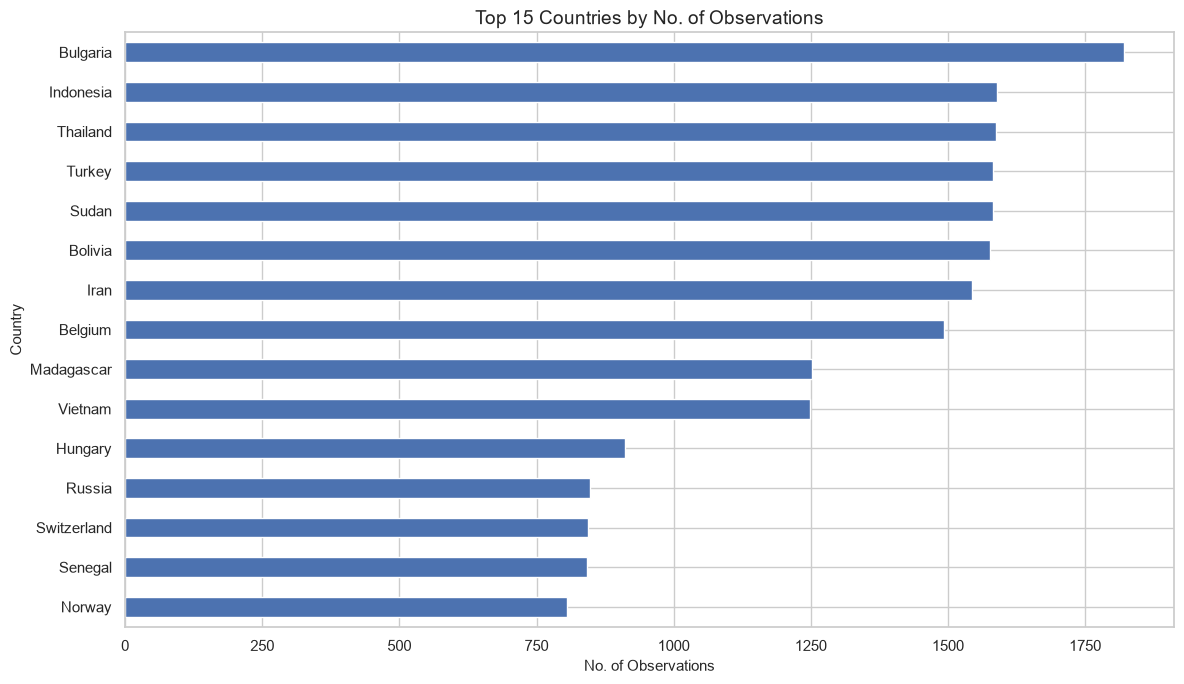

In [35]:
country_observation_counts = df_clean[Coun_Col].value_counts().head(15).sort_values()
plt.figure(figsize=(12, 7))
country_observation_counts.plot(kind="barh")
plt.title("Top 15 Countries by No. of Observations")
plt.xlabel("No. of Observations")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

Observations by Location

In [36]:
location_observation_counts = (df_clean.groupby([Coun_Col, Loc_Col]).size().reset_index(name="observation_count").sort_values("observation_count",ascending=False))
display(location_observation_counts.head(15))

,country,location_name,observation_count
36,Burundi,Bujumbura,795
260,Ukraine,Kyiv,795
278,Yemen,Sanaa,795
49,Chad,N'djamena,795
86,Ghana,Accra,795
272,Vatican City,Vatican City,795
74,Eritrea,Asmara,795
73,Equatorial Guinea,Malabo,795
149,Malta,Valletta,795
270,Uzbekistan,Tashkent,795


PLOTTING TOP LOCATIONS

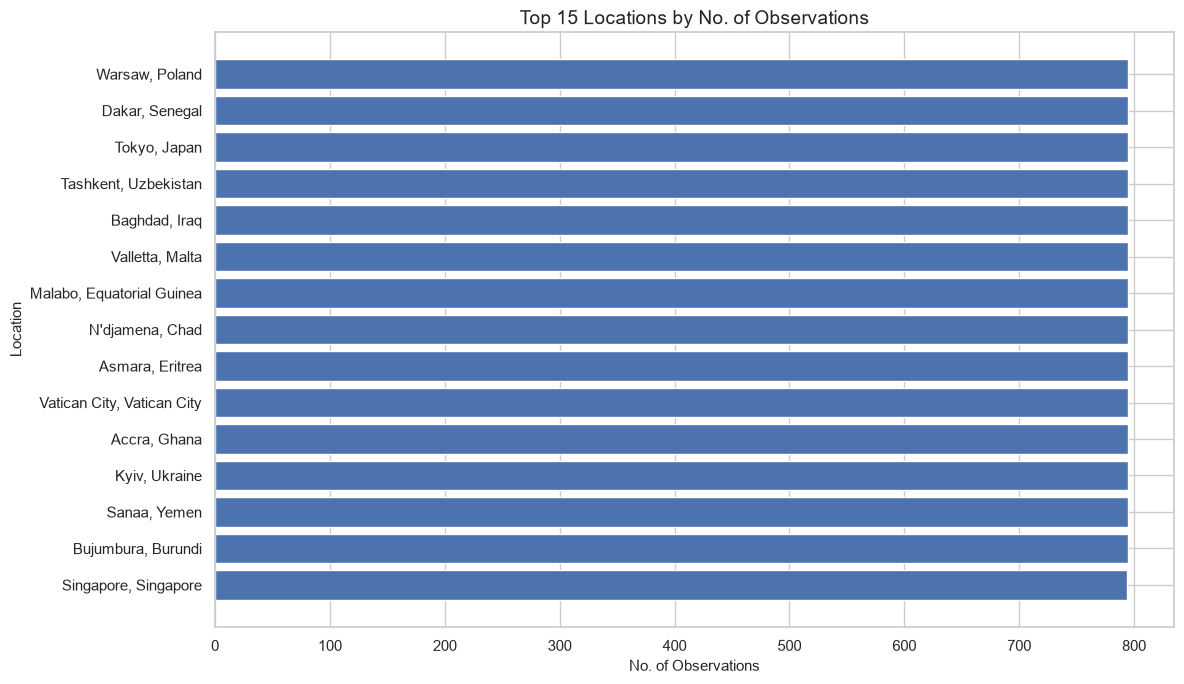

In [37]:
top_locations = (location_observation_counts.head(15).copy())
top_locations["location_label"] =top_locations[Loc_Col]+ ", "+ top_locations[Coun_Col]
top_locations = top_locations.sort_values("observation_count")
plt.figure(figsize=(12, 7))
plt.barh(top_locations["location_label"],top_locations["observation_count"])
plt.title("Top 15 Locations by No. of Observations")
plt.xlabel("No. of Observations")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

Common Weather conditions

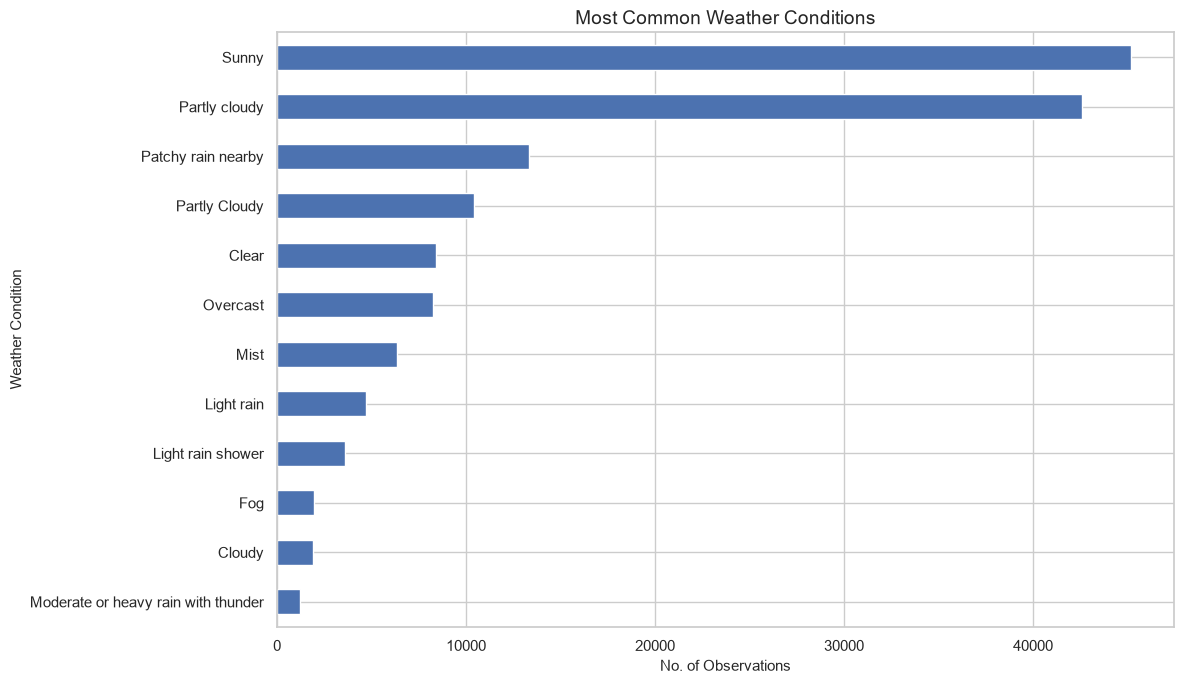

In [38]:
CONDITION_COLUMN = "condition_text"
if CONDITION_COLUMN in df_clean.columns:
    condition_counts=df_clean[CONDITION_COLUMN].value_counts().head(12).sort_values()
    plt.figure(figsize=(12, 7))
    condition_counts.plot(kind="barh")
    plt.title("Most Common Weather Conditions")
    plt.xlabel("No. of Observations")
    plt.ylabel("Weather Condition")
    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{CONDITION_COLUMN}' was not found.")

Analysing Temperature Distribution

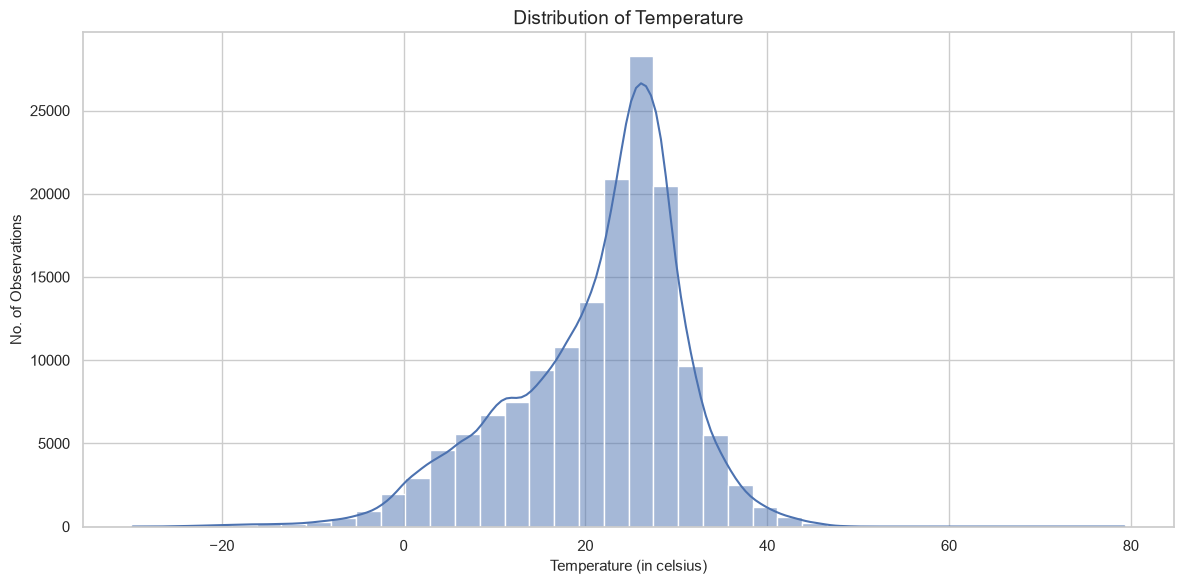

In [39]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_clean,x="temperature_celsius",bins=40,kde=True)
plt.title("Distribution of Temperature")
plt.xlabel("Temperature (in celsius)")
plt.ylabel("No. of Observations")
plt.tight_layout()
plt.show()

Humidity Distribution

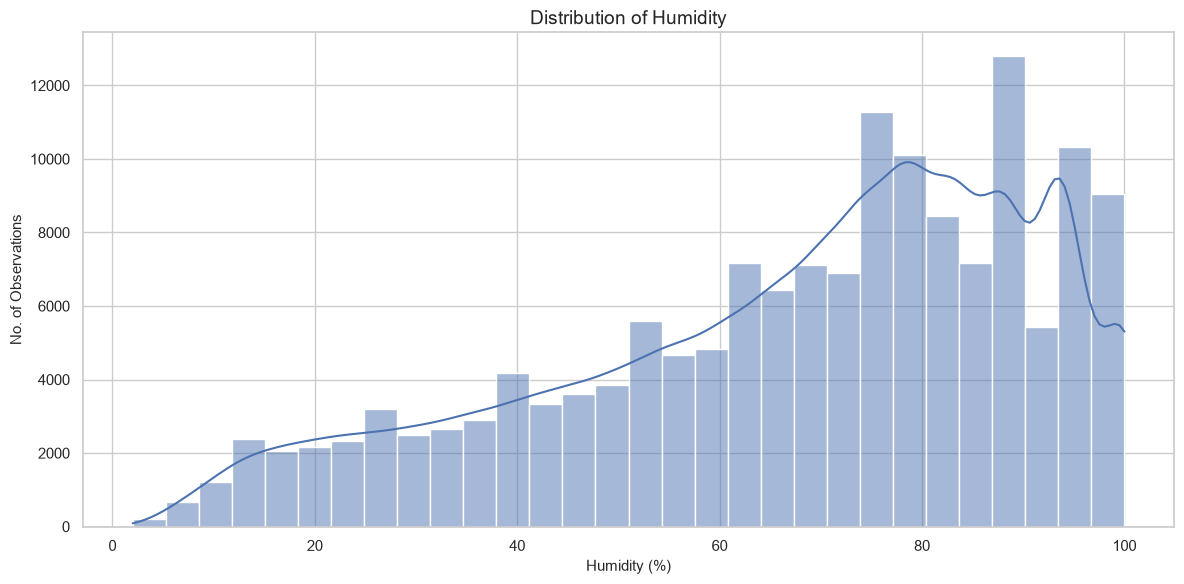

In [40]:
if "humidity" in df_clean.columns:
    plt.figure(figsize=(12, 6))
    sns.histplot(data=df_clean,x="humidity",bins=30,kde=True)
    plt.title("Distribution of Humidity")
    plt.xlabel("Humidity (%)")
    plt.ylabel("No. of Observations")
    plt.tight_layout()
    plt.show()

Wind-Speed Distribution

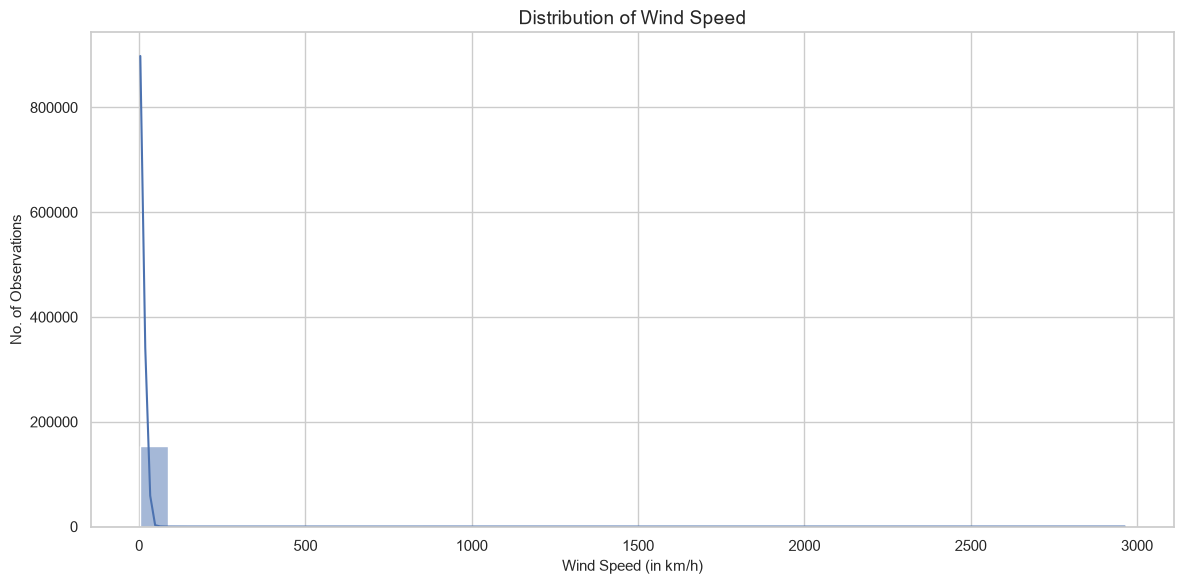

In [41]:
if "wind_kph" in df_clean.columns:
    plt.figure(figsize=(12, 6))
    sns.histplot(data=df_clean,x="wind_kph",bins=35,kde=True)
    plt.title("Distribution of Wind Speed")
    plt.xlabel("Wind Speed (in km/h)")
    plt.ylabel("No. of Observations")
    plt.tight_layout()
    plt.show()

Pressure Distribution

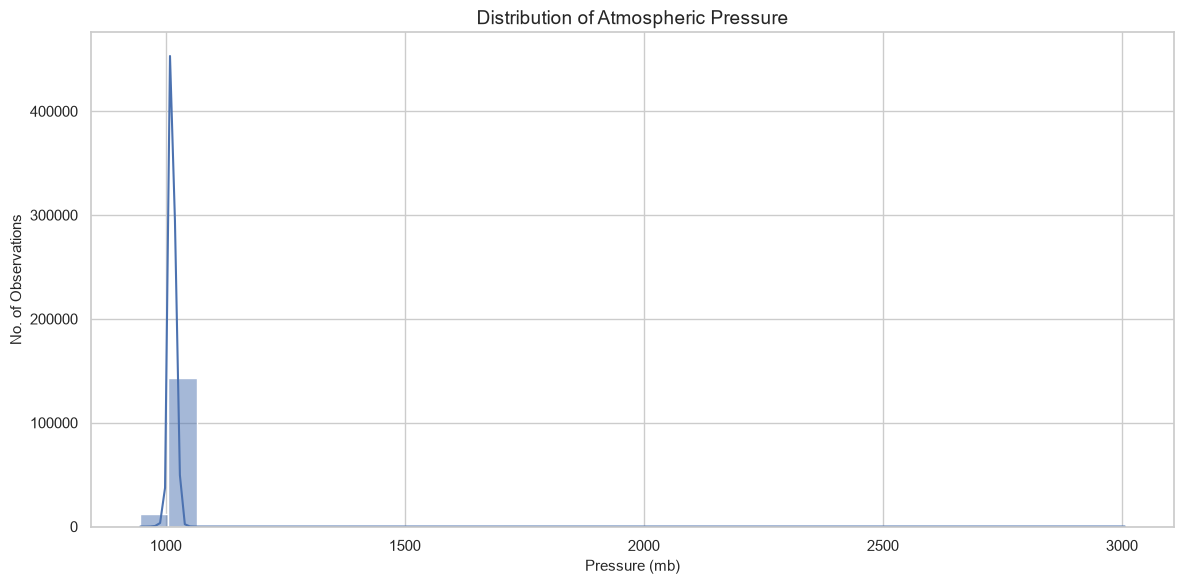

In [42]:
if "pressure_mb" in df_clean.columns:
    plt.figure(figsize=(12, 6))
    sns.histplot(data=df_clean,x="pressure_mb",bins=35,kde=True)
    plt.title("Distribution of Atmospheric Pressure")
    plt.xlabel("Pressure (mb)")
    plt.ylabel("No. of Observations")
    plt.tight_layout()
    plt.show()

Seasonal Distribution counts

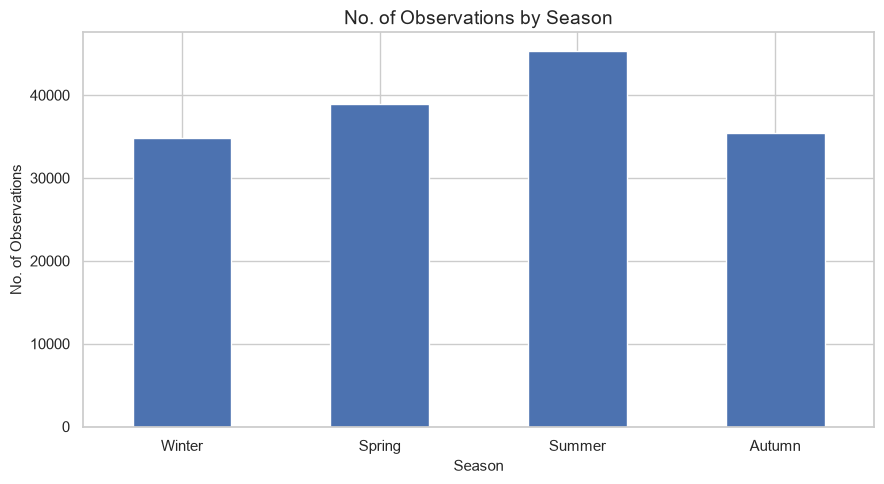

In [43]:
season_order = ["Winter","Spring","Summer","Autumn"]
season_counts = (df_clean["season"].value_counts().reindex(season_order))
plt.figure(figsize=(9, 5))
season_counts.plot(kind="bar")
plt.title("No. of Observations by Season")
plt.xlabel("Season")
plt.ylabel("No. of Observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [44]:
eda_summary = pd.DataFrame({
    "Metric": ["Cleaned rows","Cleaned columns","Countries","Country-location pairs","Weather conditions",
        "Average temperature","Average humidity","Average wind speed","Average pressure",],
    "Value": [df_clean.shape[0],df_clean.shape[1],df_clean[Coun_Col].nunique(),
        df_clean[[Coun_Col,Loc_Col]].drop_duplicates().shape[0],
        (df_clean[CONDITION_COLUMN].nunique() if CONDITION_COLUMN in df_clean.columns else "Not available"),
        (df_clean["temperature_celsius"].mean() if "temperature_celsius" in df_clean.columns else "Not available"),
        (df_clean["humidity"].mean() if "humidity" in df_clean.columns else "Not available"),
        (df_clean["wind_kph"].mean() if "wind_kph" in df_clean.columns else "Not available"),
        (df_clean["pressure_mb"].mean() if "pressure_mb" in df_clean.columns else "Not available"),]})

display(eda_summary)

,Metric,Value
0,Cleaned rows,"154,556.000"
1,Cleaned columns,51.000
2,Countries,211.000
3,Country-location pairs,286.000
4,Weather conditions,57.000
5,Average temperature,21.376
6,Average humidity,66.984
7,Average wind speed,12.771
8,Average pressure,"1,014.053"


The number of observations is generally [similar/uneven] across locations.

The most frequently recorded weather condition is [CONDITION].
The average recorded temperature is approximately [TEMPERATURE] °C.

The temperature distribution ranges from cold conditions to very high
temperatures, reflecting the global geographical coverage of the dataset.

The average humidity is approximately [HUMIDITY]%.
Most humidity observations are concentrated around [HUMIDITY RANGE]%.

Wind speed is generally concentrated at lower values, while a smaller number
of observations represent strong-wind conditions.

Atmospheric-pressure values are primarily concentrated around
[PRESSURE RANGE] mb.

Seasonal observation counts are [balanced/unbalanced], which will be
considered when interpreting seasonal patterns.

The general EDA confirms that the dataset contains sufficient weather,
geographical, and temporal information for the planned advanced analyses and
forecasting models.

#### 5. TEMPERATURE ANALYSIS

In [45]:
daily_temperature = df_clean.groupby("observation_date",as_index=False).agg(average_temperature=(TARGET_COLUMN,"mean")).sort_values("observation_date")
display(daily_temperature.head())

,observation_date,average_temperature
0,2024-05-16,23.767
1,2024-05-17,24.452
2,2024-05-18,25.356
3,2024-05-19,25.270
4,2024-05-20,25.431


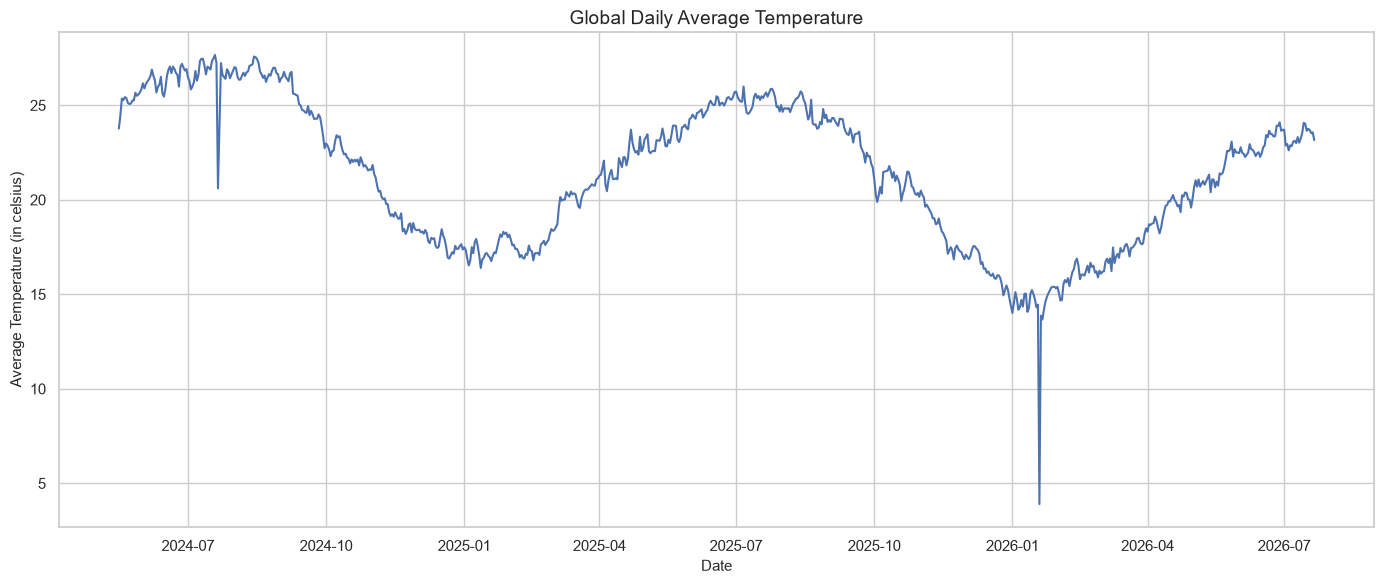

In [46]:
plt.figure(figsize=(14, 6))
plt.plot(daily_temperature["observation_date"],daily_temperature["average_temperature"])
plt.title("Global Daily Average Temperature")
plt.xlabel("Date")
plt.ylabel("Average Temperature (in celsius)")
plt.tight_layout()
plt.show()

ROLLING TEMPERATURE TRENDS

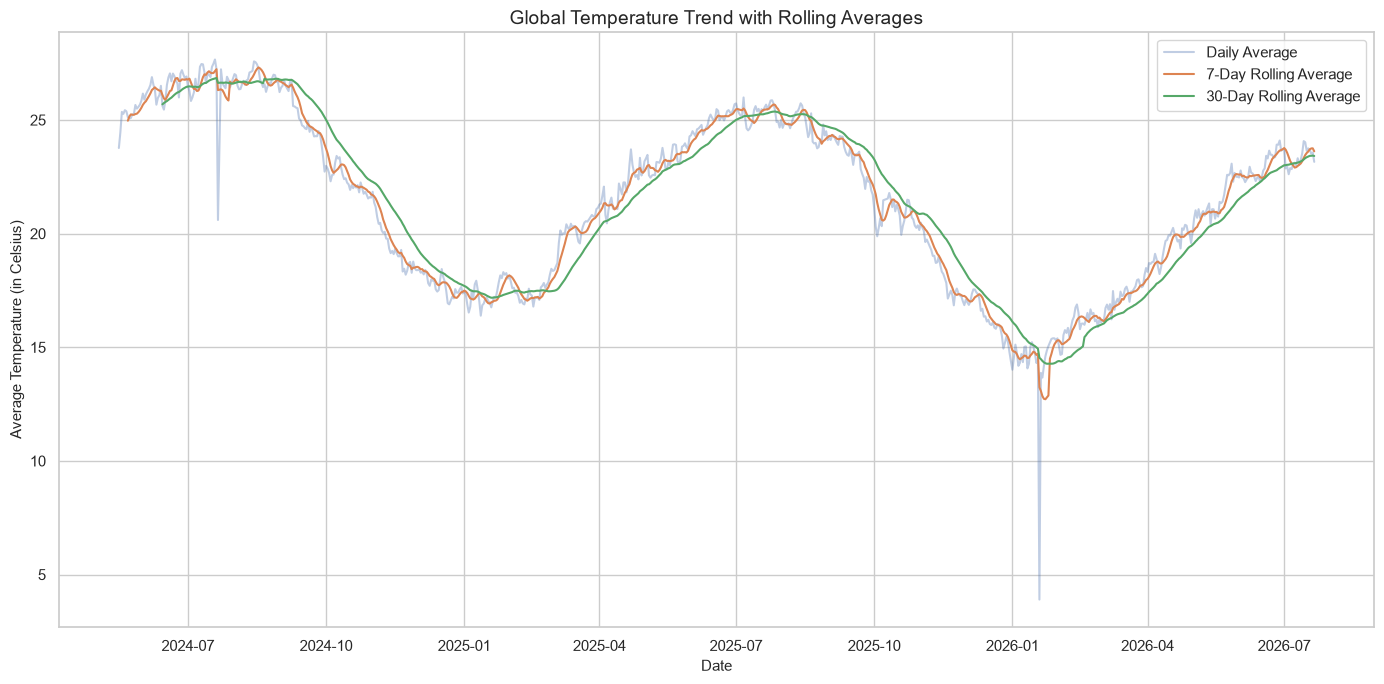

In [47]:
daily_temperature["rolling_mean_7"] = daily_temperature["average_temperature"].rolling(window=7).mean()
daily_temperature["rolling_mean_30"] =daily_temperature["average_temperature"].rolling(window=30).mean()
plt.figure(figsize=(14, 7))
plt.plot(daily_temperature["observation_date"],daily_temperature["average_temperature"],alpha=0.35,label="Daily Average")
plt.plot(daily_temperature["observation_date"],daily_temperature["rolling_mean_7"],label="7-Day Rolling Average")
plt.plot(daily_temperature["observation_date"],daily_temperature["rolling_mean_30"],label="30-Day Rolling Average")
plt.title("Global Temperature Trend with Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Average Temperature (in Celsius)")
plt.legend()
plt.tight_layout()
plt.show()

Monthly Temperature Pattern

,month,average_temperature,month_name
0,1,16.072,January
1,2,16.714,February
2,3,18.697,March
3,4,20.711,April
4,5,22.962,May
5,6,24.792,June
6,7,25.316,July
7,8,25.748,August
8,9,24.249,September
9,10,21.602,October


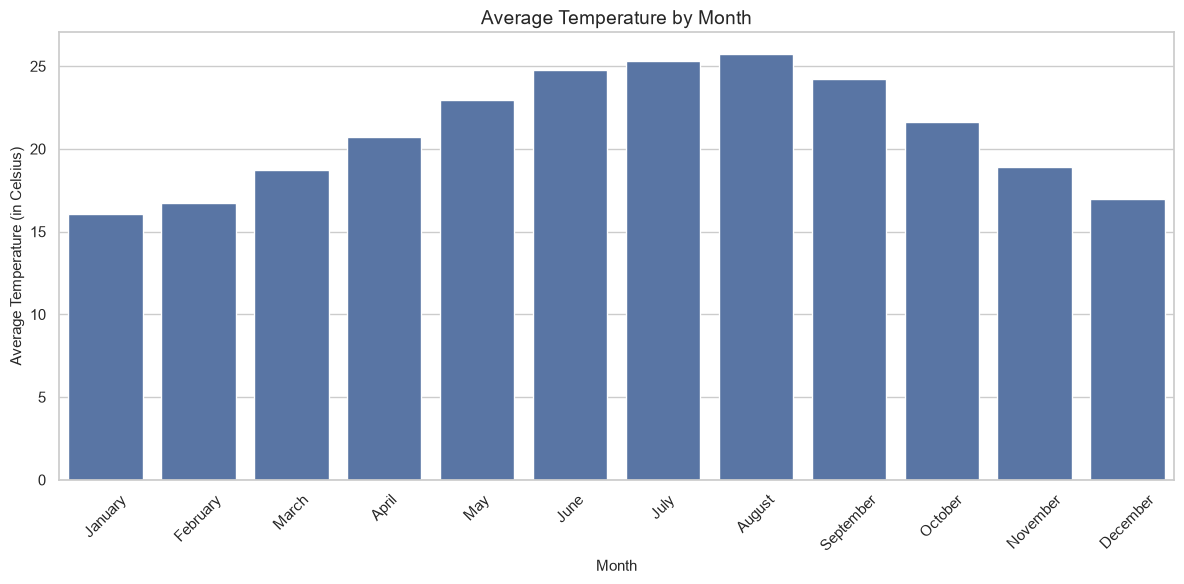

In [48]:
monthly_temperature = df_clean.groupby("month",as_index=False).agg(average_temperature=(TARGET_COLUMN,"mean")).sort_values("month")
monthly_temperature["month_name"] = pd.to_datetime(monthly_temperature["month"],format="%m").dt.month_name()
display(monthly_temperature)

plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_temperature,x="month_name",y="average_temperature")
plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average Temperature (in Celsius)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Temperature Distribution by Month

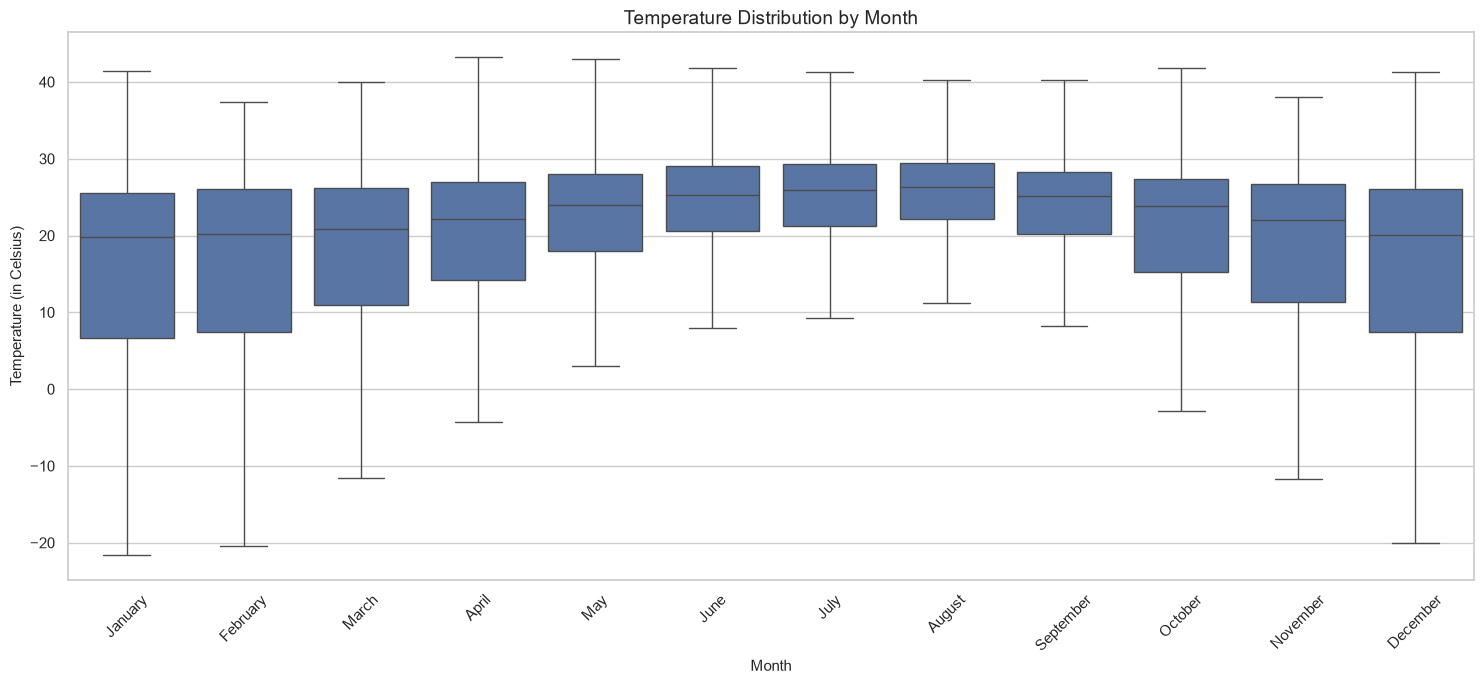

In [49]:
month= ["January","February","March","April","May","June","July","August","September","October","November","December"]
plt.figure(figsize=(15, 7))
sns.boxplot(data=df_clean,x="month_name",y=TARGET_COLUMN,order=month,showfliers=False)
plt.title("Temperature Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Temperature (in Celsius)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Location with Highest Observation Counts

In [50]:
top_temperature_locations = df_clean.groupby([Coun_Col, Loc_Col]).size().reset_index(name="observation_count").sort_values("observation_count",ascending=False).head(5)
display(top_temperature_locations)
top_location_pairs = list(top_temperature_locations[[Coun_Col, Loc_Col]].itertuples(index=False,name=None))
print("Top Location Pairs")
top_location_pairs

,country,location_name,observation_count
36,Burundi,Bujumbura,795
260,Ukraine,Kyiv,795
278,Yemen,Sanaa,795
49,Chad,N'djamena,795
86,Ghana,Accra,795


Top Location Pairs


[('Burundi', 'Bujumbura'),
 ('Ukraine', 'Kyiv'),
 ('Yemen', 'Sanaa'),
 ('Chad', "N'djamena"),
 ('Ghana', 'Accra')]

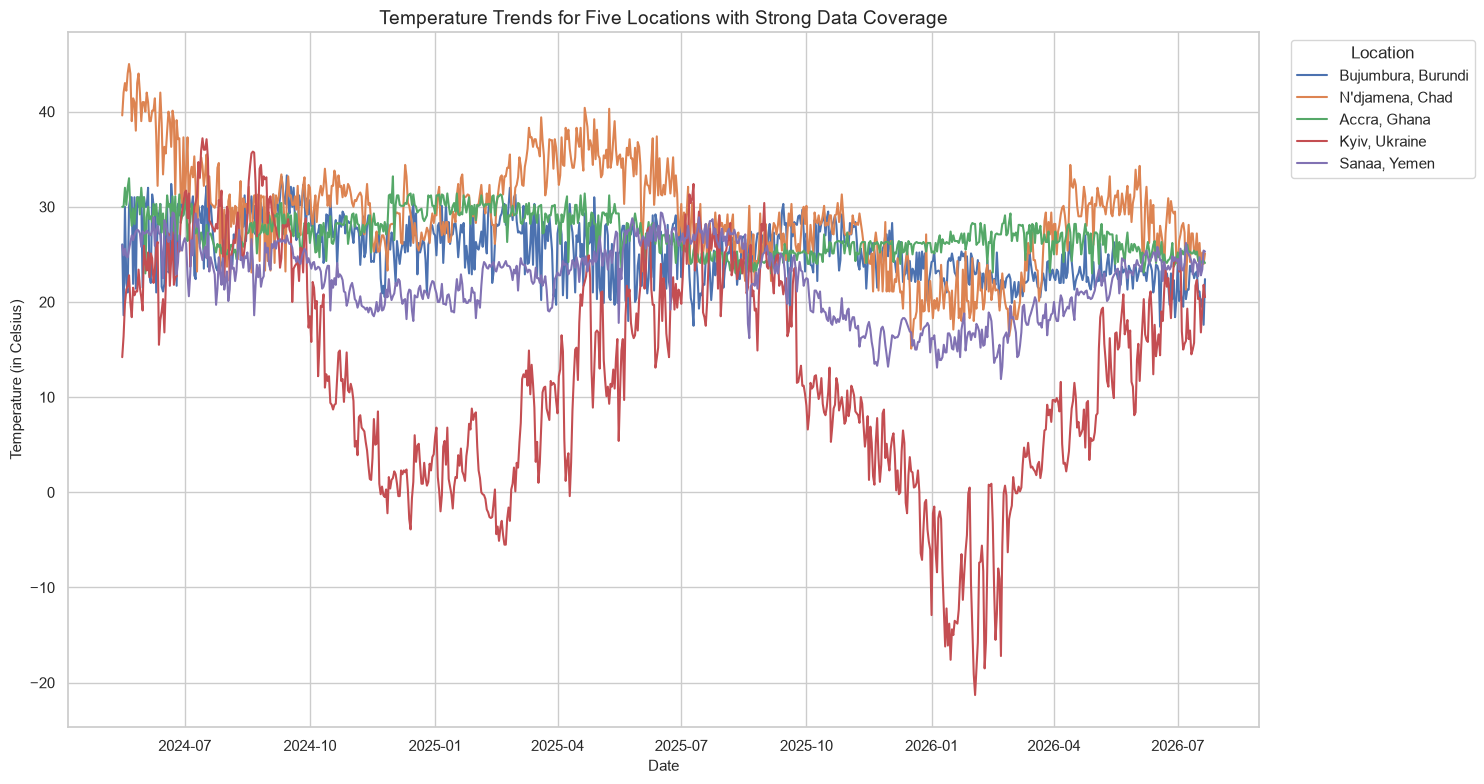

In [51]:
selected_temperature_data = df_clean[df_clean.apply(lambda row: (row[Coun_Col],row[Loc_Col]) in top_location_pairs,axis=1)].copy()
selected_temperature_data["location_label"] = selected_temperature_data[Loc_Col]+ ", "+ selected_temperature_data[Coun_Col]
plt.figure(figsize=(15, 8))
sns.lineplot(data=selected_temperature_data,x="observation_date",y=TARGET_COLUMN,hue="location_label",errorbar=None)
plt.title("Temperature Trends for Five Locations with Strong Data Coverage")
plt.xlabel("Date")
plt.ylabel("Temperature (in Celsius)")
plt.legend(title="Location",bbox_to_anchor=(1.02, 1),loc="upper left")
plt.tight_layout()
plt.show()

Location Temperature Summary

In [52]:
location_temperature_summary = (selected_temperature_data.groupby("location_label",as_index=False)
    .agg(minimum_temperature=(TARGET_COLUMN,"min"),average_temperature=(TARGET_COLUMN,"mean"),maximum_temperature=(TARGET_COLUMN,"max"),temperature_std=(TARGET_COLUMN,"std"))
    .sort_values("average_temperature",ascending=False))

display(location_temperature_summary)

,location_label,minimum_temperature,average_temperature,maximum_temperature,temperature_std
3,"N'djamena, Chad",15.100,29.199,45.000,5.289
0,"Accra, Ghana",23.000,27.142,33.200,2.097
1,"Bujumbura, Burundi",17.400,25.449,33.300,3.148
4,"Sanaa, Yemen",11.900,22.185,29.400,3.747
2,"Kyiv, Ukraine",-21.300,12.442,37.200,11.531


Plot for Location Temperature Summary

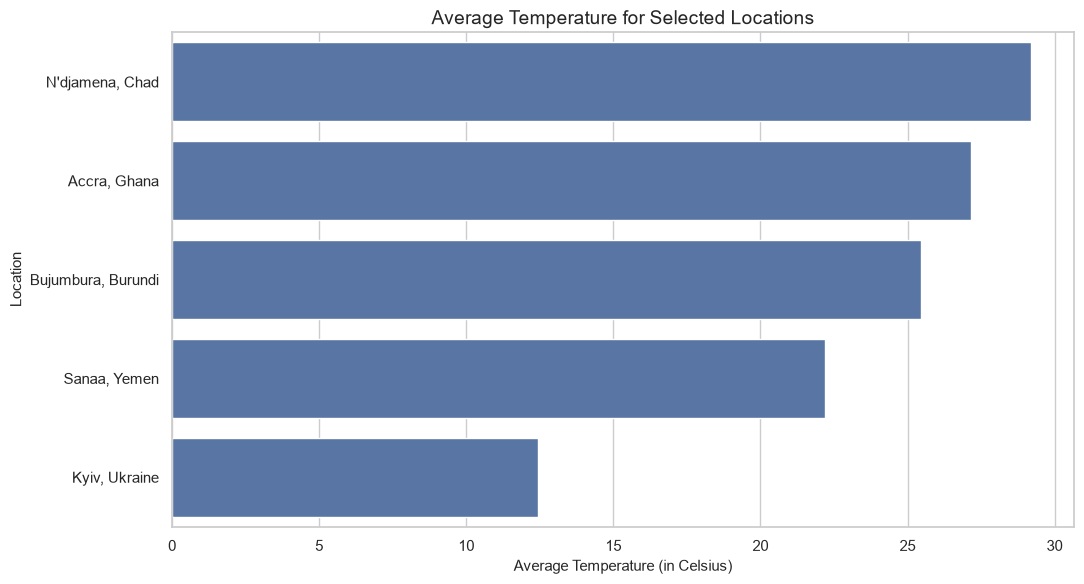

In [53]:
plt.figure(figsize=(11, 6))
sns.barplot(data=location_temperature_summary,x="average_temperature",y="location_label")
plt.title("Average Temperature for Selected Locations")
plt.xlabel("Average Temperature (in Celsius)")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

Cool and Warm month analysis

In [54]:
warmest_month = monthly_temperature.loc[monthly_temperature["average_temperature"].idxmax()]
coolest_month = monthly_temperature.loc[monthly_temperature["average_temperature"].idxmin()]

print("Warmest month:",warmest_month["month_name"],f"({warmest_month['average_temperature']:.2f} Celsius)")
print("Coolest month:",coolest_month["month_name"],f"({coolest_month['average_temperature']:.2f} Celsius)")

Warmest month: August (25.75 Celsius)
Coolest month: January (16.07 Celsius)


Highest and Lowest Average Temperature Location

In [55]:
highest_average_location = location_temperature_summary.iloc[0]
lowest_average_location = location_temperature_summary.iloc[-1]
print("Highest average temperature:",highest_average_location["location_label"],f"({highest_average_location['average_temperature']:.2f} Celsius)")
print("Lowest average temperature:",lowest_average_location["location_label"],f"({lowest_average_location['average_temperature']:.2f} Celsius)")

Highest average temperature: N'djamena, Chad (29.20 Celsius)
Lowest average temperature: Kyiv, Ukraine (12.44 Celsius)


Temperature Analysis Summary

In [56]:
temp_summary = pd.DataFrame({"Metric": ["Overall average temperature","Minimum recorded temperature","Maximum recorded temperature","Number of daily observations","Locations compared"],
    "Value": [df_clean[TARGET_COLUMN].mean(),df_clean[TARGET_COLUMN].min(),df_clean[TARGET_COLUMN].max(),daily_temperature["observation_date"].nunique(),len(top_temperature_locations)]})

display(temp_summary)

,Metric,Value
0,Overall average temperature,21.376
1,Minimum recorded temperature,-29.800
2,Maximum recorded temperature,79.300
3,Number of daily observations,796.000
4,Locations compared,5.000


The overall average temperature in the dataset is approximately
[AVERAGE TEMPERATURE] °C.
Recorded temperatures range from approximately [MINIMUM] °C to
[MAXIMUM] °C, reflecting the wide geographical coverage of the dataset.
The daily average-temperature series shows clear short-term fluctuations as
well as broader seasonal movement.
The seven-day rolling average reduces daily variation, while the 30-day
rolling average makes the longer-term temperature pattern easier to observe.
The warmest global-average month is [WARMEST MONTH], with an average
temperature of approximately [WARMEST VALUE] °C.
The coolest global-average month is [COOLEST MONTH], with an average
temperature of approximately [COOLEST VALUE] °C.
Monthly temperature distributions show substantial variation because the
dataset combines locations from different geographical regions and climate
zones.
The selected locations show visibly different temperature ranges and
seasonal patterns.
[LOCATION] has the highest average temperature among the selected
locations, while [LOCATION] has the lowest.
Temperature variability also differs across locations, demonstrating that
forecasting performance may vary by city.
These findings support using location-specific time series rather than
treating all global observations as one forecasting series.

#### 6. PRECIPITATION ANALYSIS

In [57]:
Precip_Col = "precip_mm"
if Precip_Col not in df_clean.columns:
    raise KeyError(f"Column '{Precip_Col}' was not found.")
print(f"Precipitation column selected: {Precip_Col}")

Precipitation column selected: precip_mm


Daily Average Precipitation Trend

,observation_date,average_precipitation
0,2024-05-16,0.113
1,2024-05-17,0.147
2,2024-05-18,0.128
3,2024-05-19,0.163
4,2024-05-20,0.171


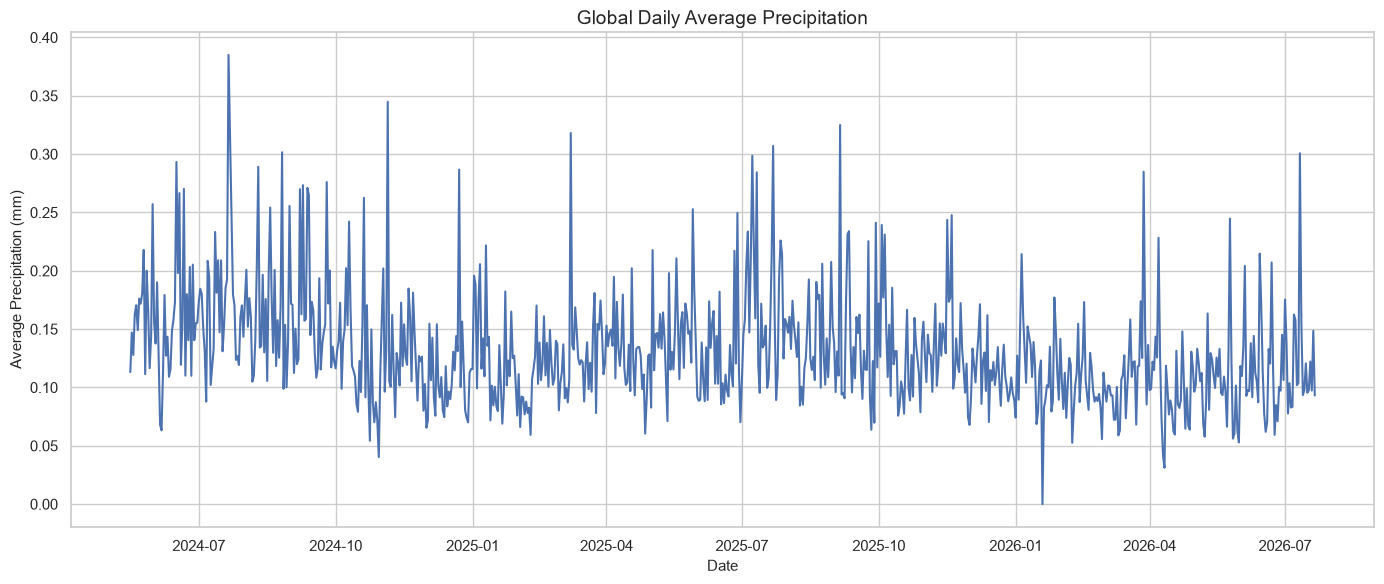

In [58]:
daily_precipitation = df_clean.groupby("observation_date",as_index=False).agg(average_precipitation=(Precip_Col,"mean")).sort_values("observation_date")

display(daily_precipitation.head())
plt.figure(figsize=(14, 6))
plt.plot(daily_precipitation["observation_date"],daily_precipitation["average_precipitation"])
plt.title("Global Daily Average Precipitation")
plt.xlabel("Date")
plt.ylabel("Average Precipitation (mm)")
plt.tight_layout()
plt.show()

Seven day rolling Precipitation average

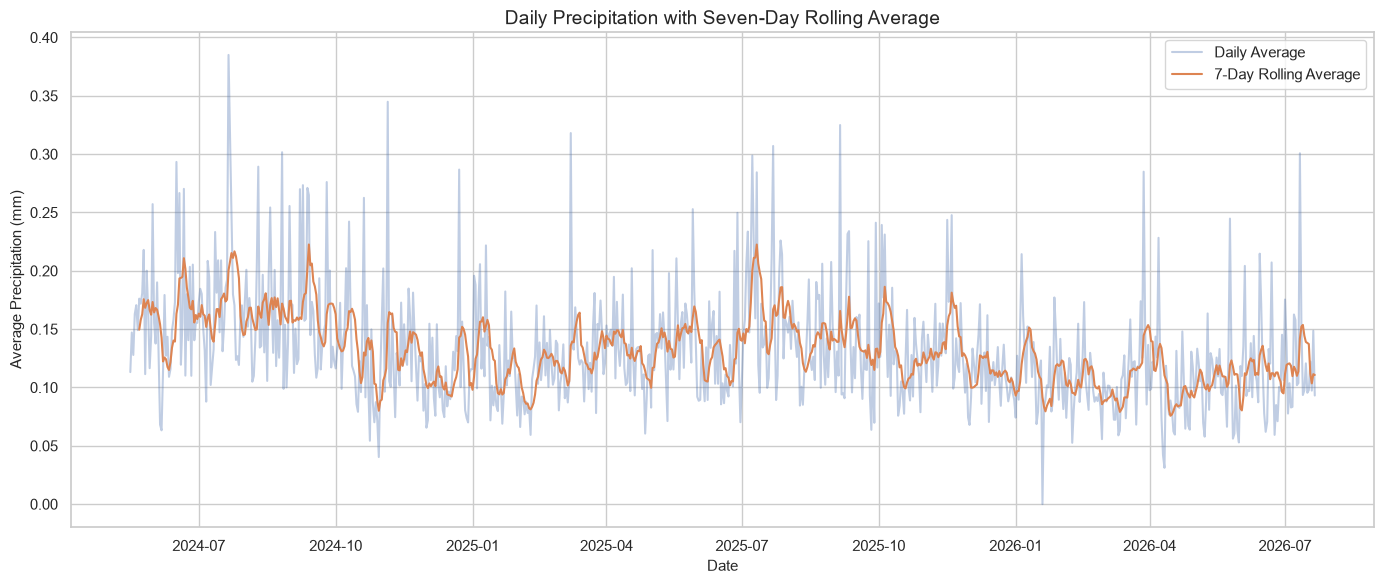

In [59]:
daily_precipitation["rolling_mean_7"]=daily_precipitation["average_precipitation"].rolling(window=7).mean()
plt.figure(figsize=(14,6))

plt.plot(daily_precipitation["observation_date"],daily_precipitation["average_precipitation"],alpha=0.35,label="Daily Average")
plt.plot(daily_precipitation["observation_date"],daily_precipitation["rolling_mean_7"],label="7-Day Rolling Average")
plt.title("Daily Precipitation with Seven-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Average Precipitation (mm)")
plt.legend()
plt.tight_layout()
plt.show()

Monthly Precipitation Pattern

,month,average_precipitation,month_name
0,1,0.122,January
1,2,0.106,February
2,3,0.122,March
3,4,0.114,April
4,5,0.133,May
5,6,0.132,June
6,7,0.156,July
7,8,0.154,August
8,9,0.153,September
9,10,0.129,October


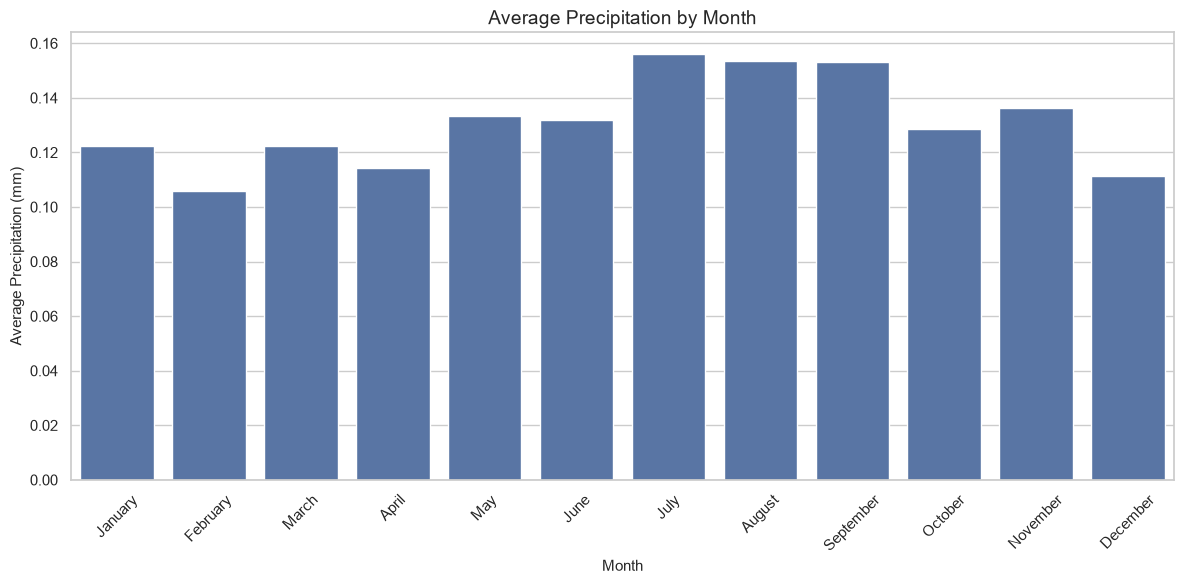

In [60]:
monthly_precipitation=df_clean.groupby("month",as_index=False).agg(average_precipitation=(Precip_Col,"mean")).sort_values("month")
monthly_precipitation["month_name"] = pd.to_datetime(monthly_precipitation["month"],format="%m").dt.month_name()
display(monthly_precipitation)
plt.figure(figsize=(12,6))
sns.barplot(data=monthly_precipitation,x="month_name",y="average_precipitation")
plt.title("Average Precipitation by Month")
plt.xlabel("Month")
plt.ylabel("Average Precipitation (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [61]:
df_clean["is_rainy_day"] = (df_clean[Precip_Col] > 0).astype(int)
rainy_day_percentage = df_clean["is_rainy_day"].mean() * 100

print(f"Percentage of rainy observations: {rainy_day_percentage:.2f}%")

Percentage of rainy observations: 32.98%


Rainy day frequency by month

,month,rainy_day_percentage,month_name
0,1,31.456,January
1,2,32.164,February
2,3,32.424,March
3,4,32.128,April
4,5,34.908,May
5,6,32.874,June
6,7,34.201,July
7,8,33.865,August
8,9,33.863,September
9,10,33.704,October


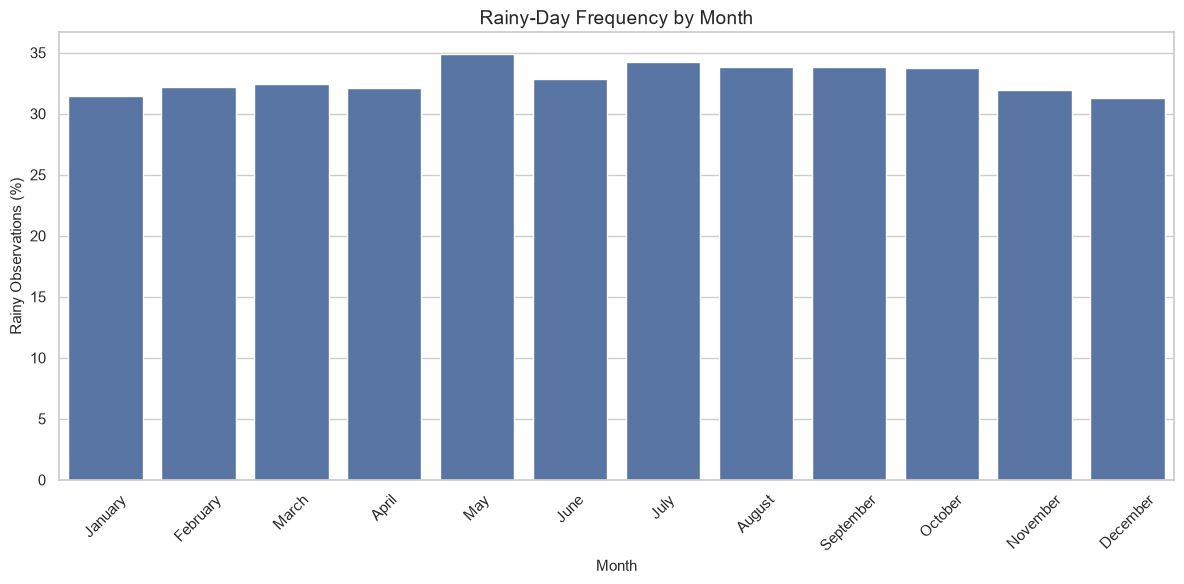

In [62]:
monthly_rainy_frequency = df_clean.groupby("month",as_index=False).agg(rainy_day_percentage=("is_rainy_day",lambda values: values.mean() * 100)).sort_values("month")
monthly_rainy_frequency["month_name"] = pd.to_datetime(monthly_rainy_frequency["month"],format="%m").dt.month_name()
display(monthly_rainy_frequency)
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_rainy_frequency,x="month_name",y="rainy_day_percentage")
plt.title("Rainy-Day Frequency by Month")
plt.xlabel("Month")
plt.ylabel("Rainy Observations (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Precipitation Comparison across selected locations

In [63]:
selected_precipitation_data = df_clean[df_clean.apply(lambda row: (row[Coun_Col],row[Loc_Col]) in top_location_pairs,axis=1)].copy()
selected_precipitation_data["location_label"] = selected_precipitation_data[Loc_Col]+ ", "+ selected_precipitation_data[Coun_Col]

Location level summary and plot

,location_label,average_precipitation,maximum_precipitation,rainy_day_percentage
1,"Bujumbura, Burundi",0.177,5.030,65.535
0,"Accra, Ghana",0.087,5.040,45.786
2,"Kyiv, Ukraine",0.052,1.870,23.774
3,"N'djamena, Chad",0.038,4.600,6.918
4,"Sanaa, Yemen",0.035,2.880,15.472


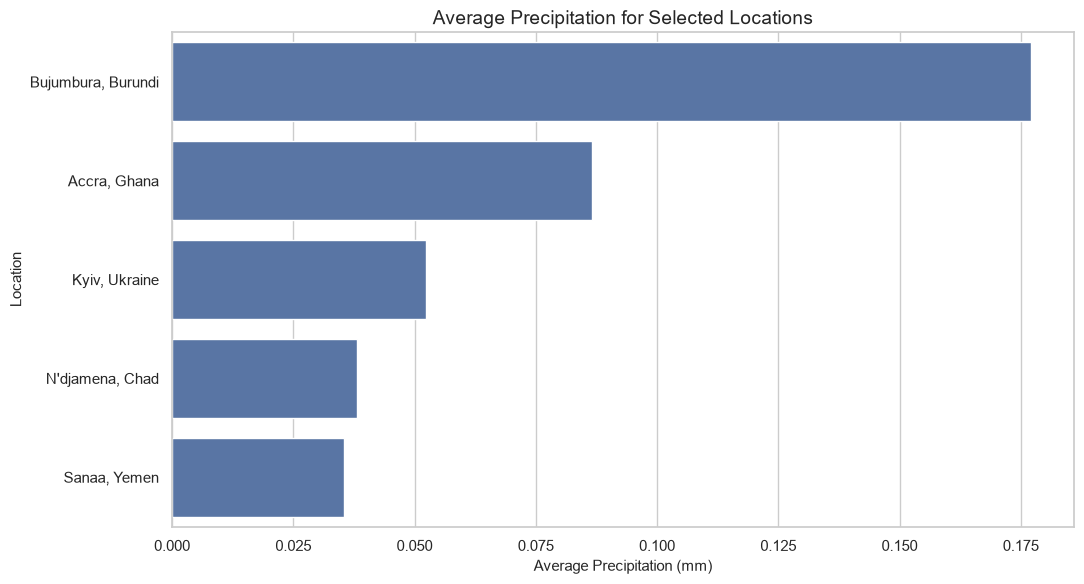

In [64]:
location_precipitation_summary = (selected_precipitation_data.groupby("location_label",
        as_index=False).agg(average_precipitation=(Precip_Col,"mean"),
        maximum_precipitation=(Precip_Col,"max"),rainy_day_percentage=("is_rainy_day",lambda values: values.mean() * 100)).sort_values("average_precipitation",ascending=False))
display(location_precipitation_summary)
plt.figure(figsize=(11, 6))
sns.barplot(data=location_precipitation_summary,x="average_precipitation",y="location_label")
plt.title("Average Precipitation for Selected Locations")
plt.xlabel("Average Precipitation (mm)")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

In [65]:
wettest_month = monthly_precipitation.loc[monthly_precipitation["average_precipitation"].idxmax()]
driest_month = monthly_precipitation.loc[monthly_precipitation["average_precipitation"].idxmin()]
print("Wettest month:",wettest_month["month_name"],f"({wettest_month['average_precipitation']:.2f} mm)")
print("Driest month:",driest_month["month_name"],f"({driest_month['average_precipitation']:.2f} mm)")

Wettest month: July (0.16 mm)
Driest month: February (0.11 mm)


In [66]:
precip_summary = pd.DataFrame({
    "Metric": ["Average precipitation","Maximum recorded precipitation","Rainy observations","Wettest month","Driest month","Locations compared"],
    "Value": [df_clean[Precip_Col].mean(),df_clean[Precip_Col].max(),f"{rainy_day_percentage:.2f}%",wettest_month["month_name"],driest_month["month_name"],len(top_location_pairs)]})
display(precip_summary)

,Metric,Value
0,Average precipitation,0.132
1,Maximum recorded precipitation,42.240
2,Rainy observations,32.98%
3,Wettest month,July
4,Driest month,February
5,Locations compared,5


Wettest Location identification

In [67]:
wettest_location = location_precipitation_summary.iloc[0]
print("Wettest selected location:",wettest_location["location_label"],f"({wettest_location['average_precipitation']:.2f} mm)")

Wettest selected location: Bujumbura, Burundi (0.18 mm)


#### 6.2 Precipitation-Analysis Findings
- The average precipitation recorded across the dataset is approximately
  **[AVERAGE PRECIPITATION] mm**.
- The maximum recorded precipitation is approximately
  **[MAXIMUM PRECIPITATION] mm**.
- Approximately **[RAINY-DAY PERCENTAGE]%** of observations contain measurable
  precipitation.
- The daily precipitation trend contains occasional spikes, indicating that
  rainfall is concentrated on fewer high-precipitation days.
- The seven-day rolling average makes broader wet and dry periods easier to
  observe.
- **[WETTEST MONTH]** has the highest average precipitation, while
  **[DRIEST MONTH]** has the lowest.
- Monthly rainy-day frequency differs across the year, showing that rainfall
  occurrence is seasonal.
- Among the selected locations, **[WETTEST LOCATION]** has the highest average
  precipitation.
- The selected locations show different rainfall amounts and rainy-day
  frequencies, indicating strong geographical variation.
- These differences support using location-specific data for weather
  forecasting rather than combining all locations into one time series.

#### 7. CORRELATION ANALYSIS

In [68]:
correlation_columns = [column for column in ["temperature_celsius","feels_like_celsius","humidity","precip_mm","cloud",
        "wind_kph","gust_kph","pressure_mb","visibility_km","uv_index",] if column in df_clean.columns]

print("Columns used for correlation analysis:")
for column in correlation_columns:
    print(f" {column}")

Columns used for correlation analysis:
 temperature_celsius
 feels_like_celsius
 humidity
 precip_mm
 cloud
 wind_kph
 gust_kph
 pressure_mb
 visibility_km
 uv_index


Computing the correlation matrix

In [69]:
correlation_matrix = (df_clean[correlation_columns].corr(method="pearson"))
display(correlation_matrix.round(2))

,temperature_celsius,feels_like_celsius,humidity,precip_mm,cloud,wind_kph,gust_kph,pressure_mb,visibility_km,uv_index
temperature_celsius,1.000,0.980,-0.340,0.030,-0.120,0.100,0.080,-0.300,0.100,0.480
feels_like_celsius,0.980,1.000,-0.240,0.060,-0.070,0.080,0.070,-0.300,0.120,0.430
humidity,-0.340,-0.240,1.000,0.170,0.500,-0.080,-0.010,0.010,-0.110,-0.550
precip_mm,0.030,0.060,0.170,1.000,0.220,0.010,0.050,-0.090,-0.030,-0.050
cloud,-0.120,-0.070,0.500,0.220,1.000,0.030,0.050,-0.070,-0.050,-0.190
wind_kph,0.100,0.080,-0.080,0.010,0.030,1.000,0.950,-0.090,0.090,0.050
gust_kph,0.080,0.070,-0.010,0.050,0.050,0.950,1.000,-0.120,0.110,-0.020
pressure_mb,-0.300,-0.300,0.010,-0.090,-0.070,-0.090,-0.120,1.000,-0.010,-0.070
visibility_km,0.100,0.120,-0.110,-0.030,-0.050,0.090,0.110,-0.010,1.000,0.030
uv_index,0.480,0.430,-0.550,-0.050,-0.190,0.050,-0.020,-0.070,0.030,1.000


Correlation Heatmap

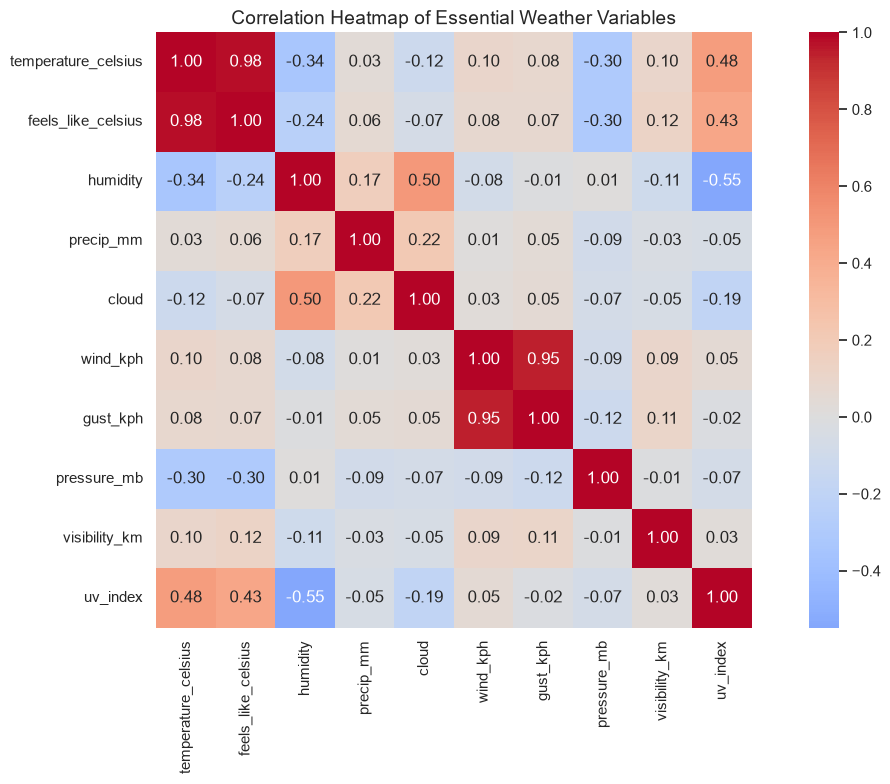

In [70]:
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",center=0,square=True)
plt.title("Correlation Heatmap of Essential Weather Variables")
plt.tight_layout()
plt.show()

Temperature Correlation

,feature,correlation_with_temperature
0,feels_like_celsius,0.980
1,uv_index,0.484
2,visibility_km,0.104
3,wind_kph,0.097
4,gust_kph,0.083
5,precip_mm,0.034
6,cloud,-0.122
7,pressure_mb,-0.298
8,humidity,-0.340


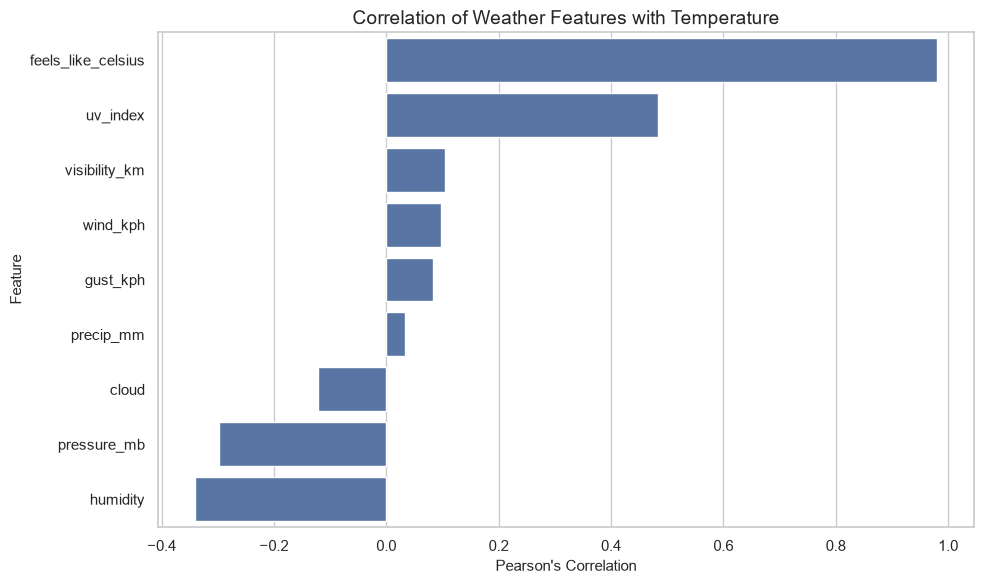

In [71]:
temperature_correlations = correlation_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False).rename("correlation_with_temperature").reset_index().rename(columns={"index": "feature"})
display(temperature_correlations)
plt.figure(figsize=(10, 6))
sns.barplot(data=temperature_correlations,x="correlation_with_temperature",y="feature")
plt.title("Correlation of Weather Features with Temperature")
plt.xlabel("Pearson's Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Temperature and feels like temperature

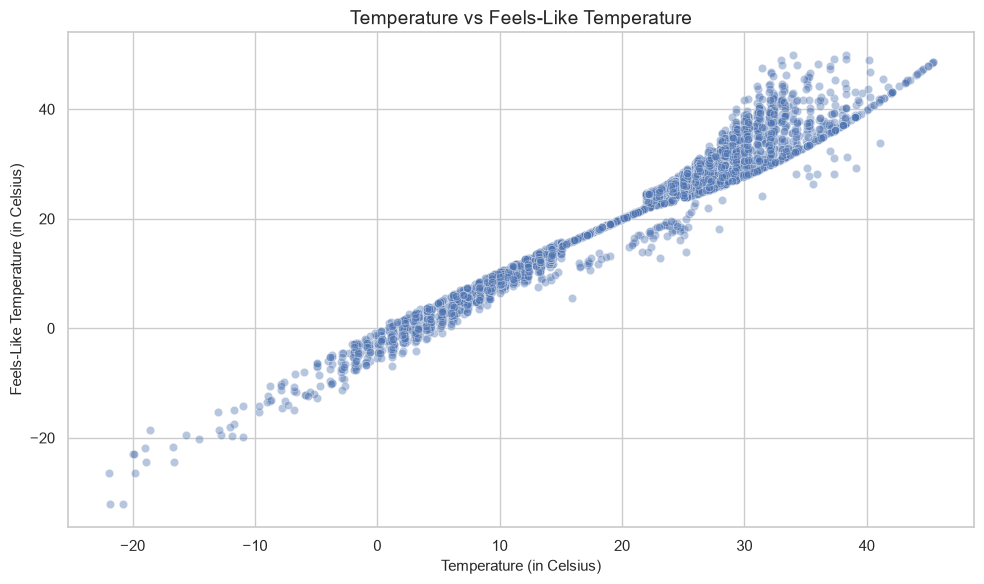

In [72]:
if "feels_like_celsius" in df_clean.columns:
    sample_data = df_clean.sample(n=min(5000, len(df_clean)),random_state=RANDOM_STATE)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=sample_data,x="temperature_celsius",y="feels_like_celsius",alpha=0.4)
    plt.title("Temperature vs Feels-Like Temperature")
    plt.xlabel("Temperature (in Celsius)")
    plt.ylabel("Feels-Like Temperature (in Celsius)")
    plt.tight_layout()
    plt.show()

Temperature and Humidity

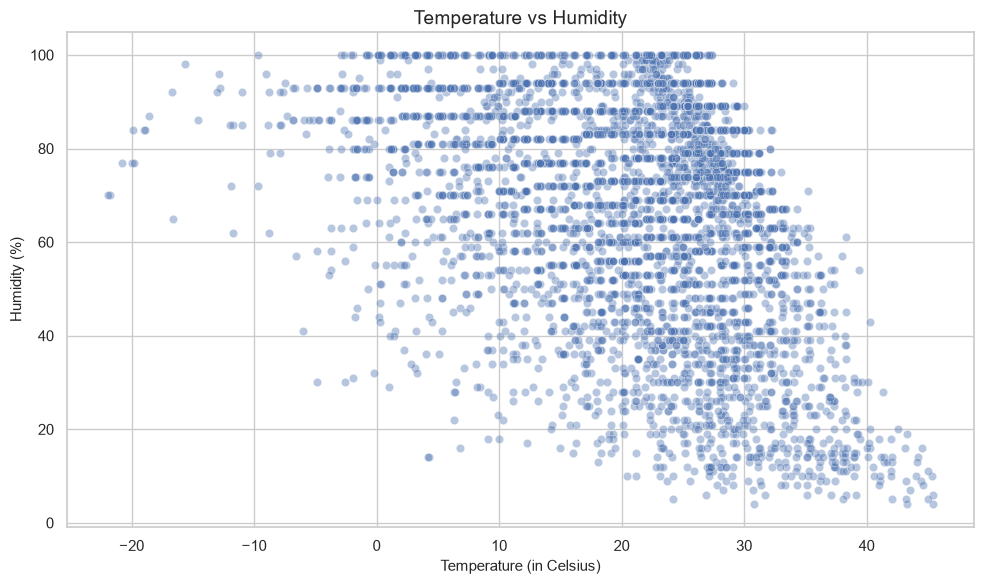

In [73]:
if "humidity" in df_clean.columns:
    sample_data = df_clean.sample(n=min(5000, len(df_clean)),random_state=RANDOM_STATE)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=sample_data,x="temperature_celsius",y="humidity",alpha=0.4)
    plt.title("Temperature vs Humidity")
    plt.xlabel("Temperature (in Celsius)")
    plt.ylabel("Humidity (%)")
    plt.tight_layout()
    plt.show()

Precipitation Correlations

,feature,correlation_with_precipitation
0,cloud,0.218
1,humidity,0.168
2,feels_like_celsius,0.061
3,gust_kph,0.047
4,temperature_celsius,0.034
5,wind_kph,0.010
6,visibility_km,-0.034
7,uv_index,-0.049
8,pressure_mb,-0.086


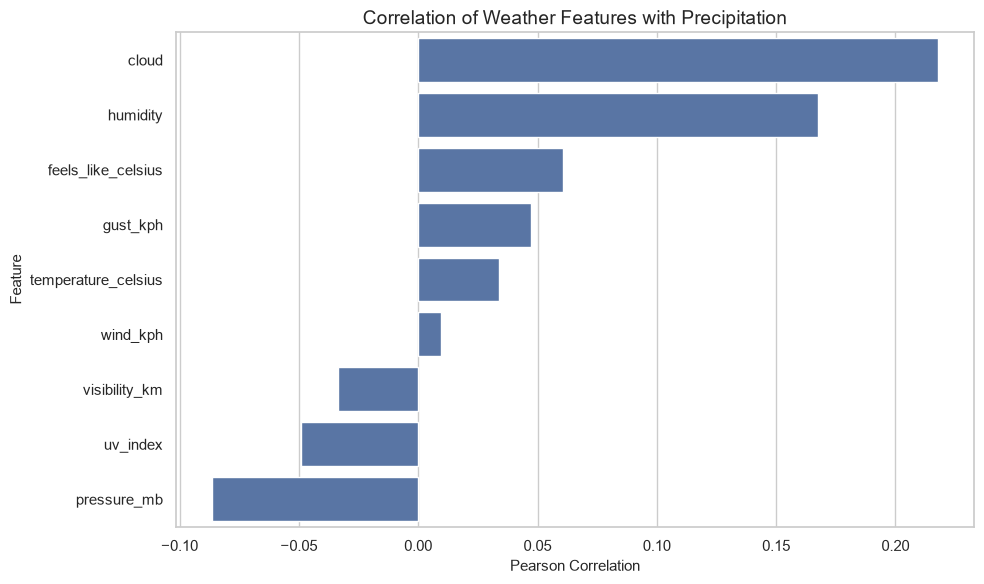

In [74]:
if Precip_Col in correlation_matrix.columns:
    precipitation_correlations = (correlation_matrix[Precip_Col].drop(Precip_Col).sort_values(ascending=False).rename("correlation_with_precipitation").reset_index().rename(columns={"index": "feature"}))
    display(precipitation_correlations)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=precipitation_correlations,x="correlation_with_precipitation",y="feature")
    plt.title("Correlation of Weather Features with Precipitation")
    plt.xlabel("Pearson Correlation")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

Precipitation and cloud cover

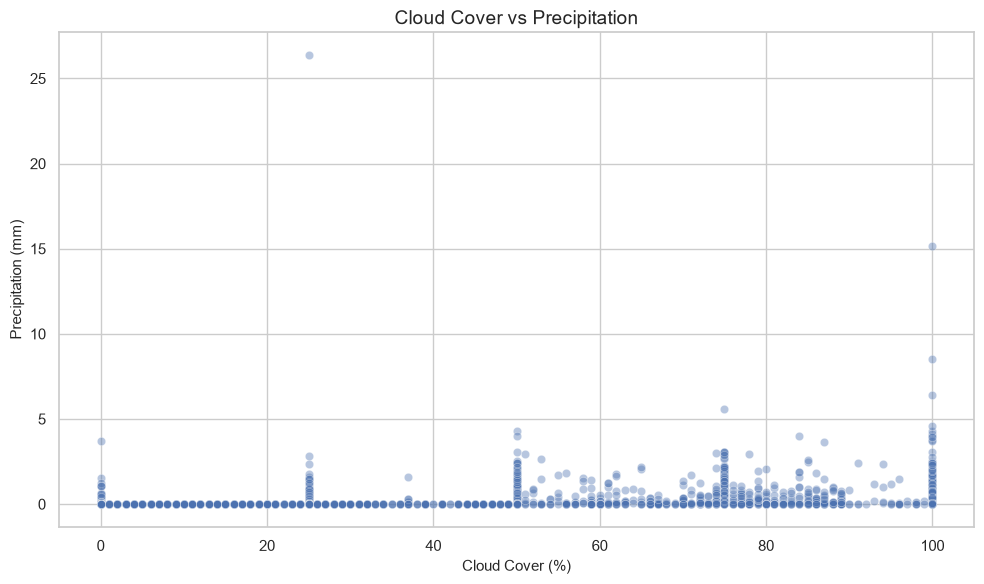

In [75]:
if ("cloud" in df_clean.columns and Precip_Col in df_clean.columns):
    sample_data = df_clean.sample(n=min(5000, len(df_clean)),random_state=RANDOM_STATE)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=sample_data,x="cloud",y=Precip_Col,alpha=0.4)
    plt.title("Cloud Cover vs Precipitation")
    plt.xlabel("Cloud Cover (%)")
    plt.ylabel("Precipitation (mm)")
    plt.tight_layout()
    plt.show()

Finding Strongest Correlations

In [76]:
correlation_pairs = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape),k=1).astype(bool)).stack().reset_index()
correlation_pairs.columns = ["feature_1","feature_2","correlation"]
correlation_pairs["absolute_correlation"] =correlation_pairs["correlation"].abs()
strongest_correlations = (correlation_pairs.sort_values("absolute_correlation",ascending=False).head(10))
display(strongest_correlations)

,feature_1,feature_2,correlation,absolute_correlation
1,temperature_celsius,feels_like_celsius,0.980,0.980
56,wind_kph,gust_kph,0.948,0.948
29,humidity,uv_index,-0.548,0.548
24,humidity,cloud,0.503,0.503
9,temperature_celsius,uv_index,0.484,0.484
19,feels_like_celsius,uv_index,0.435,0.435
2,temperature_celsius,humidity,-0.340,0.340
7,temperature_celsius,pressure_mb,-0.298,0.298
17,feels_like_celsius,pressure_mb,-0.296,0.296
12,feels_like_celsius,humidity,-0.243,0.243


Correlation Summary for Temperature

In [77]:
strongest_temperature_feature =temperature_correlations.assign(absolute_correlation=lambda data:data["correlation_with_temperature"].abs()).sort_values("absolute_correlation",ascending=False).iloc[0]
print("Strongest temperature relationship:",strongest_temperature_feature["feature"],f"({strongest_temperature_feature['correlation_with_temperature']:.2f})")

Strongest temperature relationship: feels_like_celsius (0.98)


In [78]:
if Precip_Col in correlation_matrix.columns:
    strongest_precipitation_feature = (precipitation_correlations.assign(absolute_correlation=lambda data:data["correlation_with_precipitation"].abs()).sort_values("absolute_correlation",ascending=False).iloc[0])
    print("Strongest precipitation relationship:",strongest_precipitation_feature["feature"],f"({strongest_precipitation_feature['correlation_with_precipitation']:.2f})")

Strongest precipitation relationship: cloud (0.22)


#### 7. Correlation-Analysis Findings

- Temperature has its strongest relationship with
  **`[FEATURE]`**, with a correlation of approximately **[VALUE]**.
- Temperature and feels-like temperature show a strong positive relationship,
  which is expected because perceived temperature is influenced by the actual
  air temperature.
- The relationship between temperature and humidity is
  **[positive/negative/weak]**, with a correlation of approximately
  **[VALUE]**.
- Precipitation has its strongest relationship with **`[FEATURE]`**, with a
  correlation of approximately **[VALUE]**.
- Cloud cover and precipitation show a **[weak/moderate/strong] positive
  relationship**, indicating that greater cloud cover is generally associated
  with increased rainfall.
- Visibility shows a **[positive/negative] relationship** with precipitation,
  suggesting that visibility may decrease during wetter conditions.
- Wind speed and gust speed show a strong positive relationship because both
  measure related aspects of wind intensity.
- Most weather relationships are not perfectly linear, which supports using
  nonlinear machine-learning models in addition to statistical models.
- These correlations represent associations only and should not be interpreted
  as proof that one weather variable directly causes another.

#### 8. ANOMALY DETECTION

Selecting location for anomaly detection

In [80]:
anomaly_location = (location_observation_counts.sort_values("observation_count", ascending=False).iloc[0])
anomaly_country = anomaly_location[Coun_Col]
anomaly_city = anomaly_location[Loc_Col]
print(f"Selected location: {anomaly_city}, {anomaly_country}")
print(f"Observations: {anomaly_location['observation_count']:,}")

Selected location: Bujumbura, Burundi
Observations: 795


Creating the city level dataset

In [81]:
city_anomaly_data = df_clean[(df_clean[Coun_Col] == anomaly_country)&(df_clean[Loc_Col] == anomaly_city)].copy()
city_anomaly_data = city_anomaly_data.sort_values("observation_date").reset_index(drop=True)
print(f"City-level records: {len(city_anomaly_data):,}")

City-level records: 795


Select anomaly-detection features

In [82]:
anomaly_features = [column for column in ["temperature_celsius","humidity","wind_kph","pressure_mb","precip_mm","cloud","visibility_km",] if column in city_anomaly_data.columns]
print("Features used for anomaly detection:")
for feature in anomaly_features:
    print(f" {feature}")

Features used for anomaly detection:
 temperature_celsius
 humidity
 wind_kph
 pressure_mb
 precip_mm
 cloud
 visibility_km


Preparing the anomaly data

In [84]:
anomaly_input =city_anomaly_data[anomaly_features].replace([np.inf, -np.inf], np.nan).copy()
anomaly_input = anomaly_input.fillna(anomaly_input.median())
anomaly_scaler = StandardScaler()
anomaly_input_scaled = anomaly_scaler.fit_transform(anomaly_input)

Applying Isolation Forest

In [85]:
isolation_forest = IsolationForest(n_estimators=200,contamination=0.01,random_state=RANDOM_STATE)
anomaly_predictions = isolation_forest.fit_predict(anomaly_input_scaled)
anomaly_scores = isolation_forest.decision_function(anomaly_input_scaled)

Displaying the number of anomalies 

In [87]:
city_anomaly_data["isolation_forest_prediction"] = anomaly_predictions
city_anomaly_data["anomaly_score"] = anomaly_scores
city_anomaly_data["is_anomaly"] =city_anomaly_data["isolation_forest_prediction"] == -1
anomaly_count = city_anomaly_data["is_anomaly"].sum()
anomaly_percentage =city_anomaly_data["is_anomaly"].mean()*100

print(f"Anomalies detected: {anomaly_count:,}")
print(f"Anomaly percentage: {anomaly_percentage:.2f}%")

Anomalies detected: 8
Anomaly percentage: 1.01%


Displaying detected anomalies

In [88]:
detected_anomalies = (city_anomaly_data[city_anomaly_data["is_anomaly"]].sort_values("anomaly_score"))
display(detected_anomalies[["observation_date",*anomaly_features,"anomaly_score",]])

,observation_date,temperature_celsius,humidity,wind_kph,pressure_mb,precip_mm,cloud,visibility_km,anomaly_score
2,2024-05-17,18.600,84,37.100,"1,013.000",0.830,50,10.000,-0.046
591,2025-12-29,20.100,90,8.300,"1,019.000",0.200,75,5.000,-0.034
39,2024-06-23,22.500,52,"2,963.200","1,014.000",0.000,25,10.000,-0.028
325,2025-04-07,26.300,74,7.600,"1,018.000",5.030,75,10.000,-0.025
676,2026-03-25,22.200,94,6.800,"1,013.000",2.540,50,10.000,-0.023
439,2025-07-30,25.300,47,6.800,"1,021.000",0.000,0,6.000,-0.021
645,2026-02-22,21.400,94,8.600,"1,016.000",0.100,100,6.000,-0.004
25,2024-06-09,30.200,33,41.000,"1,015.000",0.000,75,10.000,-0.001


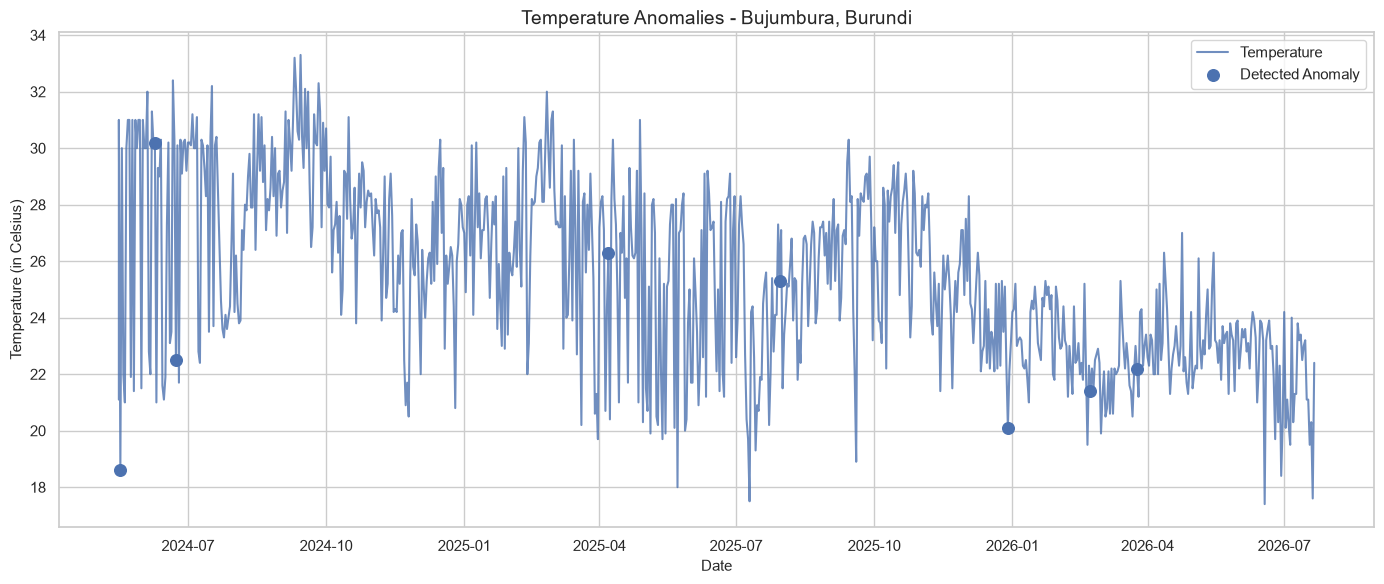

In [90]:
plt.figure(figsize=(14, 6))
plt.plot(city_anomaly_data["observation_date"],city_anomaly_data[TARGET_COLUMN],label="Temperature",alpha=0.8)
plt.scatter(detected_anomalies["observation_date"],detected_anomalies[TARGET_COLUMN],label="Detected Anomaly",s=70)
plt.title(f"Temperature Anomalies - {anomaly_city}, {anomaly_country}")
plt.xlabel("Date")
plt.ylabel("Temperature (in Celsius)")
plt.legend()
plt.tight_layout()
plt.show()

Comparison of normal and anomalous obseravtions

In [91]:
anomaly_comparison =city_anomaly_data.groupby("is_anomaly")[anomaly_features].mean().T.reset_index()
anomaly_comparison.columns = ["feature","normal_average","anomaly_average",]
anomaly_comparison["difference"] =anomaly_comparison["anomaly_average"]- anomaly_comparison["normal_average"]
display(anomaly_comparison)

,feature,normal_average,anomaly_average,difference
0,temperature_celsius,25.471,23.325,-2.146
1,humidity,63.222,71.000,7.778
2,wind_kph,7.224,384.925,377.701
3,pressure_mb,"1,014.853","1,016.125",1.272
4,precip_mm,0.168,1.087,0.920
5,cloud,52.116,56.250,4.134
6,visibility_km,9.278,8.375,-0.903


In [93]:
most_unusual_observations =city_anomaly_data.sort_values("anomaly_score").head(10)
display(most_unusual_observations[["observation_date",*anomaly_features,"anomaly_score","is_anomaly",]])

,observation_date,temperature_celsius,humidity,wind_kph,pressure_mb,precip_mm,cloud,visibility_km,anomaly_score,is_anomaly
2,2024-05-17,18.600,84,37.100,"1,013.000",0.830,50,10.000,-0.046,True
591,2025-12-29,20.100,90,8.300,"1,019.000",0.200,75,5.000,-0.034,True
39,2024-06-23,22.500,52,"2,963.200","1,014.000",0.000,25,10.000,-0.028,True
325,2025-04-07,26.300,74,7.600,"1,018.000",5.030,75,10.000,-0.025,True
676,2026-03-25,22.200,94,6.800,"1,013.000",2.540,50,10.000,-0.023,True
439,2025-07-30,25.300,47,6.800,"1,021.000",0.000,0,6.000,-0.021,True
645,2026-02-22,21.400,94,8.600,"1,016.000",0.100,100,6.000,-0.004,True
25,2024-06-09,30.200,33,41.000,"1,015.000",0.000,75,10.000,-0.001,True
673,2026-03-22,20.500,90,3.600,"1,014.000",0.200,85,5.000,0.000,False
633,2026-02-10,21.300,94,3.600,"1,018.000",0.000,75,5.000,0.007,False


In [94]:
anomaly_summary = pd.DataFrame({
    "Metric": ["Location analyzed","Observations analyzed","Features used","Anomalies detected","Anomaly percentage",],
    "Value": [f"{anomaly_city}, {anomaly_country}",len(city_anomaly_data),len(anomaly_features),anomaly_count,f"{anomaly_percentage:.2f}%",],})
display(anomaly_summary)

,Metric,Value
0,Location analyzed,"Bujumbura, Burundi"
1,Observations analyzed,795
2,Features used,7
3,Anomalies detected,8
4,Anomaly percentage,1.01%


- Isolation Forest was applied to weather observations from
  **[CITY, COUNTRY]**, which had strong historical data coverage.
- The model analyzed **[NUMBER OF OBSERVATIONS] observations** using
  temperature, humidity, wind speed, pressure, precipitation, cloud cover,
  and visibility.
- The model identified **[ANOMALY COUNT] anomalous observations**, representing
  approximately **[ANOMALY PERCENTAGE]%** of the location's records.
- The detected anomalies were associated with unusual combinations of multiple
  weather variables rather than temperature alone.
- Compared with normal observations, anomalous records showed
  **[HIGHER/LOWER] temperature**, **[HIGHER/LOWER] precipitation**, and
  **[STRONGER/WEAKER] wind conditions** on average.
- Some anomalies also contained unusual atmospheric-pressure, cloud-cover, or
  visibility measurements.
- The anomaly dates were retained because they may represent genuine extreme
  weather events rather than data errors.
- Isolation Forest complements the earlier IQR method by identifying unusual
  multivariable weather patterns.
- The results demonstrate that anomaly detection can reveal rare weather
  conditions that may not be identified by examining one feature independently.